# CarRacing-v3 SAC Fast Result - Final Clean Notebook

**SAC fast-result branch - 400K best checkpoint (partial run, not 500K)**

_Project: Visual Reinforcement Learning for Randomized CarRacing-v3 - PPO Baseline, Generalization, and Speed._

---

> **SAFE MODE / REPORT-ONLY.** This is a cleaned final-release notebook. Training cells are disabled by default (`ALLOW_TRAINING=False`). It is intended for evaluation, figure/table generation, and the written report. See the Configuration cell for the safety flags.

## Project Overview

This notebook is the **SAC fast-result branch** for randomized CarRacing-v3 (speed-first single-env configuration). SAC is trained from scratch over the same engineered visual features as the PPO baseline and evaluated with the same COMPARE5 / RANDOM10 / bootstrap-CI protocol.

> **Status: 400K best-checkpoint / partial run.** This SAC fast-result run reached a best evaluation checkpoint at **400K** and is **not** treated as a completed 500K run (the log progresses to ~83% with no eval checkpoint beyond 400K). Early stopping reflects Colab runtime limits / fast-result intent.


## Setup

Install dependencies and mount Drive / set output paths. In Colab, run the install cell first, then restart the runtime.

In [1]:
# Install dependencies (run FIRST, then restart runtime)

import subprocess, sys

def _run(cmd, check=True):
    print(f"$ {cmd}")
    r = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    if r.stdout: print(r.stdout[-1500:])
    if r.returncode != 0:
        print(r.stderr[-2000:])
        if check: raise RuntimeError(f"Failed: {cmd}")

_run("apt-get update -qq && apt-get install -y -qq swig build-essential ffmpeg", check=False)
_run(f"{sys.executable} -m pip install -q --no-cache-dir swig")
_run(f"{sys.executable} -m pip install -q --upgrade --no-cache-dir "
    "'stable-baselines3>=2.5.0' 'gymnasium[box2d]>=0.29.1' "
    "opencv-python-headless imageio imageio-ffmpeg matplotlib pandas")

for p in ["numpy", "stable-baselines3", "gymnasium"]:
    _run(f"{sys.executable} -m pip show {p} | grep -E 'Name|Version'", check=False)

print("\nDone. RESTART RUNTIME NOW, then run Cell 2 onward.")


$ apt-get update -qq && apt-get install -y -qq swig build-essential ffmpeg
Selecting previously unselected package swig4.0.
(Reading database ... 
(Reading database ... 5%
(Reading database ... 10%
(Reading database ... 15%
(Reading database ... 20%
(Reading database ... 25%
(Reading database ... 30%
(Reading database ... 35%
(Reading database ... 40%
(Reading database ... 45%
(Reading database ... 50%
(Reading database ... 55%
(Reading database ... 60%
(Reading database ... 65%
(Reading database ... 70%
(Reading database ... 75%
(Reading database ... 80%
(Reading database ... 85%
(Reading database ... 90%
(Reading database ... 95%
(Reading database ... 100%
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubuntu1_all.deb ...
Unpacking swig (4.0.2-1ubuntu1) ...
Setting up swig4.0 (4.

In [2]:
# Drive mount + output paths

import os, shutil

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    _DRIVE_OK = True
except Exception:
    _DRIVE_OK = False
    print("Drive not available -- saving locally only")

# Separate output root for this experiment. NEVER write into other experiment folders or evidence dirs.
DRIVE_ROOT = "/content/drive/MyDrive/carracing-ppo/v11_1_sac_fast_result"
LOCAL_ROOT = "/content/carracing_ppo_v11_1_sac_fast_result"
# Forbidden write targets (asserted below):
_V9_LOCAL_ROOT    = "/content/carracing_ppo_v9"
_V9_DRIVE_ROOT    = "/content/drive/MyDrive/carracing-ppo/v9"
# Must NOT write into other experiments' run dirs either:
_V10_LOCAL_ROOT   = "/content/carracing_ppo_v10_sac"
_V10_DRIVE_ROOT   = "/content/drive/MyDrive/carracing-ppo/v10_sac"
# (other prior experiment dirs are also forbidden write targets):
_V105_LOCAL_ROOT  = "/content/carracing_ppo_v10_5_sac_optimized"
# (this run only READS any prior dirs, it never writes into them):
_V11_LOCAL_ROOT   = "/content/carracing_ppo_v11_sac_main"
_V11_DRIVE_ROOT   = "/content/drive/MyDrive/carracing-ppo/v11_sac_main"
_V105_DRIVE_ROOT  = "/content/drive/MyDrive/carracing-ppo/v10_5_sac_optimized"
_FORBIDDEN_DIRS   = [
    _V9_LOCAL_ROOT, _V9_DRIVE_ROOT, _V10_LOCAL_ROOT, _V10_DRIVE_ROOT, _V105_LOCAL_ROOT, _V105_DRIVE_ROOT, _V11_LOCAL_ROOT, _V11_DRIVE_ROOT,
    "/content/completed_run_evidence", "completed_run_evidence",
    "/content/evidence_logs", "evidence_logs",
    "/content/output", "output",
]

RAPID_DIR   = f"{LOCAL_ROOT}/rapid_50k"
OFFICIAL_DIR= f"{LOCAL_ROOT}/official_500k"
CKPT_DIR    = f"{OFFICIAL_DIR}/checkpoints"
BEST_DIR    = f"{OFFICIAL_DIR}/best"
LOG_DIR     = f"{LOCAL_ROOT}/logs"
TABLE_DIR   = f"{LOCAL_ROOT}/tables"
FIG_DIR     = f"{LOCAL_ROOT}/figures"
VIDEO_DIR   = f"{LOCAL_ROOT}/videos"
RELEASE_DIR = f"{LOCAL_ROOT}/release"

for d in [RAPID_DIR, CKPT_DIR, BEST_DIR, LOG_DIR, TABLE_DIR, FIG_DIR, VIDEO_DIR, RELEASE_DIR,
          f"{RAPID_DIR}/checkpoints", f"{RAPID_DIR}/best"]:
    os.makedirs(d, exist_ok=True)
if _DRIVE_OK:
    for s in ["rapid_50k", "official_500k/checkpoints", "official_500k/best",
              "logs", "tables", "figures", "videos", "release"]:
        os.makedirs(f"{DRIVE_ROOT}/{s}", exist_ok=True)


def _backup(path):
    if not _DRIVE_OK or not os.path.isfile(path): return
    rel = os.path.relpath(path, LOCAL_ROOT)
    dst = f"{DRIVE_ROOT}/{rel}"
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    shutil.copy2(path, dst)


def _kb(p): return os.path.getsize(p) / 1024 if os.path.isfile(p) else 0.0


print(f"Local: {LOCAL_ROOT}  Drive: {DRIVE_ROOT}  OK={_DRIVE_OK}")

# --- path safety: print resolved dirs + assert no V9/evidence/output overlap
for _name, _p in [("OFFICIAL_DIR", OFFICIAL_DIR), ("CKPT_DIR", CKPT_DIR),
                  ("BEST_DIR", BEST_DIR), ("RELEASE_DIR", RELEASE_DIR),
                  ("LOG_DIR", LOG_DIR), ("RAPID_DIR", RAPID_DIR)]:
    print(f"  {_name:13s}= {_p}")
_real_local = os.path.realpath(LOCAL_ROOT)
for _fb in _FORBIDDEN_DIRS:
    _rfb = os.path.realpath(_fb)
    # This run's root must neither be inside a forbidden dir nor contain it.
    assert _real_local != _rfb, f"V10 LOCAL_ROOT equals forbidden dir: {_fb}"
    assert not _real_local.startswith(_rfb + os.sep), \
        f"V10 LOCAL_ROOT is inside forbidden dir: {_fb}"
    assert not _rfb.startswith(_real_local + os.sep), \
        f"V10 LOCAL_ROOT would contain forbidden dir: {_fb}"
# The PPO baseline root must not equal or nest this run's root (and vice versa).
assert _real_local != os.path.realpath(_V9_LOCAL_ROOT), "V10 root == V9 local root!"
assert _real_local != os.path.realpath(_V9_DRIVE_ROOT), "V10 root == V9 drive root!"
print("  [OK] output paths do not overwrite the PPO baseline, other experiments, evidence, or output dirs.")


Mounted at /content/drive
Local: /content/carracing_ppo_v11_1_sac_fast_result  Drive: /content/drive/MyDrive/carracing-ppo/v11_1_sac_fast_result  OK=True
  V11 OFFICIAL_DIR = /content/carracing_ppo_v11_1_sac_fast_result/official_500k
  V11 CKPT_DIR     = /content/carracing_ppo_v11_1_sac_fast_result/official_500k/checkpoints
  V11 BEST_DIR     = /content/carracing_ppo_v11_1_sac_fast_result/official_500k/best
  V11 RELEASE_DIR  = /content/carracing_ppo_v11_1_sac_fast_result/release
  V11 LOG_DIR      = /content/carracing_ppo_v11_1_sac_fast_result/logs
  V11 RAPID_DIR    = /content/carracing_ppo_v11_1_sac_fast_result/rapid_50k
  [OK] V11 paths do not overwrite V9/V10/V10.5/evidence/output dirs.


In [3]:
import os, shutil, glob, re

print("RESTORE FROM DRIVE → LOCAL")
print("DRIVE_ROOT:", DRIVE_ROOT)
print("LOCAL_ROOT:", LOCAL_ROOT)

assert os.path.isdir(DRIVE_ROOT), f"Drive root not found: {DRIVE_ROOT}"

# Copy saved artifacts from Drive back to /content local paths
for sub in ["official_500k", "logs", "tables", "figures", "videos", "release"]:
    src = os.path.join(DRIVE_ROOT, sub)
    dst = os.path.join(LOCAL_ROOT, sub)
    if os.path.isdir(src):
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print("RESTORED:", src, "->", dst)
    else:
        print("MISSING ON DRIVE:", src)

# If best_model.zip was not backed up, reconstruct best from latest checkpoint
os.makedirs(BEST_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

def step_num(path):
    nums = re.findall(r"\d+", os.path.basename(path))
    return int(nums[-1]) if nums else -1

best_model = os.path.join(BEST_DIR, "best_model.zip")
best_norm  = os.path.join(BEST_DIR, "best_vecnormalize.pkl")

ckpt_models = sorted(glob.glob(os.path.join(CKPT_DIR, "*_steps.zip")), key=step_num)
ckpt_norms  = sorted(glob.glob(os.path.join(CKPT_DIR, "vecnorm_*_steps.pkl")), key=step_num)

print("\nCheckpoint models:", ckpt_models[-5:])
print("Checkpoint norms:", ckpt_norms[-5:])

if not os.path.isfile(best_model) and ckpt_models:
    latest_model = ckpt_models[-1]
    shutil.copy2(latest_model, best_model)
    print("RECONSTRUCTED best_model from:", latest_model)

if not os.path.isfile(best_norm) and ckpt_norms:
    latest_norm = ckpt_norms[-1]
    shutil.copy2(latest_norm, best_norm)
    print("RECONSTRUCTED best_vecnormalize from:", latest_norm)

print("\nKEY FILE CHECK:")
for p in [
    best_model,
    best_norm,
    os.path.join(BEST_DIR, "evaluations.npz"),
]:
    print(("OK " if os.path.isfile(p) else "MISS "), p,
          os.path.getsize(p)/1024 if os.path.isfile(p) else 0, "KB")

RESTORE FROM DRIVE → LOCAL
DRIVE_ROOT: /content/drive/MyDrive/carracing-ppo/v11_1_sac_fast_result
LOCAL_ROOT: /content/carracing_ppo_v11_1_sac_fast_result
RESTORED: /content/drive/MyDrive/carracing-ppo/v11_1_sac_fast_result/official_500k -> /content/carracing_ppo_v11_1_sac_fast_result/official_500k
RESTORED: /content/drive/MyDrive/carracing-ppo/v11_1_sac_fast_result/logs -> /content/carracing_ppo_v11_1_sac_fast_result/logs
RESTORED: /content/drive/MyDrive/carracing-ppo/v11_1_sac_fast_result/tables -> /content/carracing_ppo_v11_1_sac_fast_result/tables
RESTORED: /content/drive/MyDrive/carracing-ppo/v11_1_sac_fast_result/figures -> /content/carracing_ppo_v11_1_sac_fast_result/figures
RESTORED: /content/drive/MyDrive/carracing-ppo/v11_1_sac_fast_result/videos -> /content/carracing_ppo_v11_1_sac_fast_result/videos
RESTORED: /content/drive/MyDrive/carracing-ppo/v11_1_sac_fast_result/release -> /content/carracing_ppo_v11_1_sac_fast_result/release

Checkpoint models: ['/content/carracing_ppo_

In [4]:
import os, shutil

ckpt_400_model = os.path.join(CKPT_DIR, "rl_400000_steps.zip")
ckpt_400_norm  = os.path.join(CKPT_DIR, "vecnorm_400000_steps.pkl")

best_model = os.path.join(BEST_DIR, "best_model.zip")
best_norm  = os.path.join(BEST_DIR, "best_vecnormalize.pkl")

assert os.path.isfile(ckpt_400_model), ckpt_400_model
assert os.path.isfile(ckpt_400_norm), ckpt_400_norm

shutil.copy2(ckpt_400_model, best_model)
shutil.copy2(ckpt_400_norm, best_norm)

print("FORCED BEST PAIR = 400K checkpoint")
print("best_model:", best_model, os.path.getsize(best_model)/1024, "KB")
print("best_norm :", best_norm, os.path.getsize(best_norm)/1024, "KB")

FORCED BEST PAIR = 400K checkpoint
best_model: /content/carracing_ppo_v11_1_sac_fast_result/official_500k/best/best_model.zip 3642.646484375 KB
best_norm : /content/carracing_ppo_v11_1_sac_fast_result/official_500k/best/best_vecnormalize.pkl 3.591796875 KB


## Configuration

All knobs live in one place. The final release adds `SAFE_MODE` / `REPORT_ONLY` / `EVAL_ONLY` / `ALLOW_TRAINING` flags so the notebook runs report/eval-only by default.

In [5]:
# Central configuration (ALL knobs in one place)

import sys, os, time, hashlib, warnings, shutil, base64, json
import numpy as np
import cv2
import gymnasium as gym
import stable_baselines3 as sb3
import torch
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import imageio

%matplotlib inline

from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import (
    DummyVecEnv, VecFrameStack, VecNormalize,
)
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import (
    BaseCallback, CheckpointCallback, EvalCallback,
)
from stable_baselines3.common.env_checker import check_env
from IPython.display import HTML, display as ipy_display
from typing import Callable

warnings.filterwarnings("ignore", category=UserWarning)

# ---- Version gate ----
np_major = int(np.__version__.split(".")[0])
sb3_ver  = tuple(int(x) for x in sb3.__version__.split(".")[:2])
if np_major >= 2:
    assert sb3_ver >= (2, 5), f"NumPy {np.__version__} needs SB3>=2.5, got {sb3.__version__}"
import Box2D

# ==========================================
# RUN_MODE
# ==========================================
RUN_MODE = "EVAL_ONLY"  # EVAL_ONLY (default: report/eval only) | SMOKE_ONLY | RAPID_50K | OFFICIAL_500K

# ==========================================
# Environment
# ==========================================
CAR_RACING_ENV_ID = "CarRacing-v3"
PERCEPTION_MODE   = "v6_full_mask"  # "v6_full_mask" | "connected_mask"

# ==========================================
# Training
# ==========================================
SEED            = 42
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"
TOTAL_TIMESTEPS = 500_000
N_STACK         = 4
CROP_BOTTOM     = 84
ACTION_REPEAT   = 2

# ==========================================
# V10 SAC profile (main-branch fair-comparison config)
# ------------------------------------------
# N_ENVS=1 is the chosen fair-comparison implementation. SAC can technically
# use VecEnv in SB3, but N_ENVS=1 is the main-branch decision to avoid added
# complexity, replay-buffer interaction issues, and confounds. Any multi-env
# SAC variant must be a SEPARATE ablation branch.
# ==========================================
N_ENVS          = 1      # V11.1 FAST_RESULT: Colab 2-vCPU path, DummyVecEnv (no Subproc probe)
VEC_MIN_SPEEDUP = 1.5    # if smoke probe vec/single throughput < this, auto-fallback to N_ENVS=1
USE_SUBPROC     = False  # V11.1: N_ENVS=1 -> resolve_nenvs() short-circuits, no probe

# --- SAC-specific hyperparameters (algorithm's own operating params) ---------
BUFFER_SIZE     = 200_000   # 200k: more diversity than 100k, safer than 500k on
                            # Colab free tier. Fallback to 100_000 only if smoke/
                            # rapid shows RAM/save-time problems (documented as a
                            # SAC runtime constraint, NOT an obs/reward/wrapper change).
LEARNING_STARTS = 10_000    # V11: more random data before updates; counters the early ent_coef over-collapse seen in the V10 log
                            # diversity (10k) and early signal (1k).
TAU             = 0.005     # SB3-SAC default soft-update rate.
SAC_BATCH_SIZE  = 256       # SB3-SAC default; PPO's 128 is tied to n_steps rollout.
# ── V11.1 FAST_RESULT speed lever: reduce SAC update DENSITY (UTD<1) ──────────
# gradient_steps is FIXED at 1; train_freq batches env steps before each single
# update. Fewer updates per env step => real speedup, but NOT strictly comparable
# to V11's UTD=1 gradient-compute budget. This is an explicit, disclosed trade-off.
SPEED_MODE = "AGGRESSIVE"   # FAST_RESULT | AGGRESSIVE | STRICT
_SPEED = {
    "FAST_RESULT": dict(train_freq=(4, "step"), label="fast-result (default): 1 update / 4 env steps"),
    "AGGRESSIVE":  dict(train_freq=(8, "step"), label="aggressive: 1 update / 8 env steps (stronger disclosure)"),
    "STRICT":      dict(train_freq=(1, "step"), label="strict reference: 1 update / 1 env step (= V11 UTD=1)"),
}
assert SPEED_MODE in _SPEED, f"SPEED_MODE must be one of {list(_SPEED)}"
TRAIN_FREQ     = _SPEED[SPEED_MODE]["train_freq"]
GRADIENT_STEPS = 1                                   # FIXED for all speed modes
_TF_STEPS      = TRAIN_FREQ[0]
UPDATE_DENSITY = GRADIENT_STEPS / (_TF_STEPS * N_ENVS)   # FAST_RESULT 0.25 | AGGRESSIVE 0.125 | STRICT 1.00
DISCLOSURE_LABEL = _SPEED[SPEED_MODE]["label"]
LEARNING_RATE   = 3e-4      # constant -- off-policy; PPO LR schedule is tied to
                            # rollout progress and does not transfer.
SAC_ENT_COEF    = "auto"    # adaptive entropy; do not hand-tune to look good.
TARGET_ENTROPY  = "auto"    # = -action_dim = -3.
USE_SDE         = False     # OFF. Proposal-to-evaluate only; never a requirement.
                            # Any use_sde variant is a separate ablation branch.

# --- shared with V9 (fairness) ----------------------------------------------
GAMMA           = 0.99      # INVARIANT: matches V9 + VecNormalize.
# Notes:
#   * N_STEPS / N_EPOCHS / INIT_CLIP / FINAL_CLIP / GAE_LAMBDA / VF_COEF are
#     PPO-only and intentionally DROPPED. They do not exist in SAC.
#   * ENT_COEF=0.01 (PPO fixed) is replaced by SAC_ENT_COEF="auto".
#   * clip_schedule is removed in the schedules cell.

# ==========================================
# Wrapper constants (V9 changes marked)
# ==========================================
EMA_ALPHA        = 0.40
MAX_OFFROAD      = 25
MAX_STILL        = 50
STILL_SPEED_THR  = 0.03
OFFROAD_PEN      = 0.30
STEER_PEN        = 0.04
TILE_BONUS       = 0.50
STEERING_GUIDE   = 0.15
SPEED_BONUS      = 0.02
FRONT_DANGER_PEN = 0.20
GRASS_LOW        = np.array([28,  35,  35],  dtype=np.uint8)
GRASS_HIGH       = np.array([92, 255, 255],  dtype=np.uint8)
RAY_ANGLES_DEG   = np.array([-70, -52.5, -35, -17.5, 0, 17.5, 35, 52.5, 70], dtype=np.float32)
RAY_ORIGIN       = (48, 70)

# ==========================================
# Observation (V9: 16D = 14D + front_ray_delta + left_right_asymmetry)
# ==========================================
OBS_DIM_BASE    = 16
OBS_DIM_STACKED = OBS_DIM_BASE * N_STACK  # 64

# ==========================================
# Checkpoint / eval
# ==========================================
CKPT_FREQ    = 25_000 // N_ENVS
EVAL_FREQ    = 20_000 // N_ENVS
N_EVAL_EPS   = 5

RAPID_TIMESTEPS = 50_000
RAPID_EVAL_FREQ = 10_000 // N_ENVS
RAPID_CKPT_FREQ = 25_000 // N_ENVS

# ── V10.5 PROFILE + RUN_MODE resolver ─────────────────────────────────────────
# safe_fast = operational-only optimization, FULLY fair-comparable to V10
# (no algorithm hyperparameter / wrapper / obs / reward / eval-seed change).
PROFILE = "v11_sac_main"   # single design -- no profile tournament (rationale: V11_design_notes.md)
_PROFILES = {
    "v11_sac_main":     dict(eval_freq=25_000, replay_save_freq=100_000),
    "v10_current":      dict(eval_freq=20_000, replay_save_freq=25_000),
    "v10_5_safe_fast":  dict(eval_freq=25_000, replay_save_freq=100_000),
    "v10_5_fast_stable":dict(eval_freq=40_000, replay_save_freq=100_000),
    "v10_5_aggressive": dict(eval_freq=25_000, replay_save_freq=100_000),
}
assert PROFILE in _PROFILES, f"unknown PROFILE {PROFILE}"
_pf = _PROFILES[PROFILE]
EVAL_FREQ        = 50_000 // N_ENVS    # V11.1: eval every 50k env steps (fewer eval pauses)
CKPT_FREQ        = 50_000 // N_ENVS    # V11.1: checkpoint every 50k env steps
REPLAY_SAVE_FREQ = _pf["replay_save_freq"]         # replay buffer saved at multiples of this (+ best + final)
# aggressive-only algorithm knob (ISOLATED, NOT fair-comparable; revert to 1 if no time-to-score gain)
if PROFILE == "v10_5_aggressive":
    pass  # V11: no aggressive UTD override; UTD fixed at 1 via gradient_steps=-1
# RUN_MODE -> total timesteps for THIS run
_RAPID_MODES    = {"RAPID_50K": 50_000, "RAPID_80K": 80_000, "RAPID_120K": 120_000}
_OFFICIAL_MODES = {"OFFICIAL_300K": 300_000, "OFFICIAL_500K": 500_000}
if RUN_MODE in _RAPID_MODES:    RAPID_TIMESTEPS = _RAPID_MODES[RUN_MODE]
if RUN_MODE in _OFFICIAL_MODES: TOTAL_TIMESTEPS = _OFFICIAL_MODES[RUN_MODE]
_IS_RAPID    = RUN_MODE in _RAPID_MODES
_IS_OFFICIAL = RUN_MODE in _OFFICIAL_MODES
print(f"PROFILE={PROFILE}  EVAL_FREQ={EVAL_FREQ*N_ENVS:,}  REPLAY_SAVE_FREQ={REPLAY_SAVE_FREQ:,}")
print(f"RUN_MODE={RUN_MODE}  RAPID_TIMESTEPS={RAPID_TIMESTEPS:,}  TOTAL_TIMESTEPS={TOTAL_TIMESTEPS:,}")

COMPARE5_SEEDS       = [42, 123, 777, 999, 2026]
RANDOM10_MASTER_SEED = 42
RANDOM10_COUNT       = 10

VIDEO_FPS = 30
MODEL_TO_EVALUATE = "best"

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | SB3 {sb3.__version__}")
print(f"gym {gym.__version__} | torch {torch.__version__} | CUDA {torch.cuda.is_available()}")
if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"\nRUN_MODE          = {RUN_MODE}")
print(f"PERCEPTION_MODE   = {PERCEPTION_MODE}")
print(f"DEVICE={DEVICE}  N_ENVS={N_ENVS}  TOTAL={TOTAL_TIMESTEPS:,}")
print(f"ALGORITHM=SAC  USE_SDE={USE_SDE}")
print(f"BUFFER={BUFFER_SIZE}  LEARNING_STARTS={LEARNING_STARTS}  BATCH={SAC_BATCH_SIZE}  TAU={TAU}")
print(f"SPEED_MODE={SPEED_MODE}  TRAIN_FREQ={TRAIN_FREQ}  GRADIENT_STEPS={GRADIENT_STEPS}")
print(f"UPDATE_DENSITY={UPDATE_DENSITY:.3f} updates/env-step  ({DISCLOSURE_LABEL})")
print(f"ENT_COEF={SAC_ENT_COEF}  TARGET_ENTROPY={TARGET_ENTROPY}  LR={LEARNING_RATE}")
print(f"EMA_ALPHA={EMA_ALPHA}  OFFROAD_PEN={OFFROAD_PEN}")
print(f"OBS={OBS_DIM_BASE}D x {N_STACK} = {OBS_DIM_STACKED}D  (INVARIANT vs V9)")
print("\n[STAGE 3] Keep RUN_MODE='SMOKE_ONLY'. Do NOT set RAPID_50K or OFFICIAL_500K")
print("          until smoke PASS + user approval.")
if RUN_MODE in ("RAPID_50K", "RAPID_80K", "RAPID_120K", "OFFICIAL_300K", "OFFICIAL_500K"):
    print(f"  [!] RUN_MODE={RUN_MODE} will TRAIN when you reach the training cell.")
    print("      Only proceed if smoke has PASSED and the user approved this run.")


# === FINAL CLEAN RELEASE - SAFE MODE FLAGS (added during cleanup) ===
# This notebook ships report/eval-only. Training cells are guarded by these.
SAFE_MODE     = True    # master safety switch for the final release
REPORT_ONLY   = True    # build figures/tables/report from saved artifacts only
EVAL_ONLY     = True    # run evaluation from saved artifacts only
ALLOW_TRAINING = False  # set True ONLY if you intentionally want to re-train


PROFILE=v11_sac_main  EVAL_FREQ=50,000  REPLAY_SAVE_FREQ=100,000
RUN_MODE=EVAL_ONLY  RAPID_TIMESTEPS=50,000  TOTAL_TIMESTEPS=500,000
Python 3.12.13 | NumPy 2.0.2 | SB3 2.9.0
gym 1.3.0 | torch 2.11.0+cpu | CUDA False

RUN_MODE          = EVAL_ONLY
PERCEPTION_MODE   = v6_full_mask
DEVICE=cpu  N_ENVS=1  TOTAL=500,000
ALGORITHM=SAC  USE_SDE=False
BUFFER=200000  LEARNING_STARTS=10000  BATCH=256  TAU=0.005
SPEED_MODE=AGGRESSIVE  TRAIN_FREQ=(8, 'step')  GRADIENT_STEPS=1
UPDATE_DENSITY=0.125 updates/env-step  (aggressive: 1 update / 8 env steps (stronger disclosure))
ENT_COEF=auto  TARGET_ENTROPY=auto  LR=0.0003
EMA_ALPHA=0.4  OFFROAD_PEN=0.3
OBS=16D x 4 = 64D  (INVARIANT vs V9)

[STAGE 3] Keep RUN_MODE='SMOKE_ONLY'. Do NOT set RAPID_50K or OFFICIAL_500K
          until smoke PASS + user approval.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tz

In [6]:
# Schedules + utilities


def linear_schedule(init_val: float, final_val: float) -> Callable[[float], float]:
    def _s(p: float) -> float:
        return final_val + p * (init_val - final_val)
    return _s


lr_schedule = linear_schedule(LEARNING_RATE, LEARNING_RATE)  # constant for SAC
# clip_schedule removed: SAC has no clip_range. (PPO-only.)
SAC_LR_CONSTANT = LEARNING_RATE  # used directly in SAC(...) build calls


def _hash_array(arr, n=12):
    return hashlib.md5(np.asarray(arr).tobytes()).hexdigest()[:n]


def _render_rgb_from_vec(vec):
    cur = vec
    while hasattr(cur, "venv"):
        cur = cur.venv
    if not hasattr(cur, "envs"):
        raise RuntimeError("Cannot unwrap to DummyVecEnv")
    env0 = cur.envs[0]
    frame = env0.render()
    if frame is None:
        try: frame = env0.unwrapped.render()
        except Exception: pass
    if frame is None:
        raise RuntimeError("Could not render raw RGB frame.")
    return np.asarray(frame)


def _first_frame_hash(vec):
    return _hash_array(_render_rgb_from_vec(vec))


class TrainMetricsLogger(BaseCallback):
    # SAC logger keys (V10). PPO-only keys (approx_kl, clip_fraction,
    # policy_gradient_loss, value_loss) are intentionally absent in SAC.
    _KEYS = ["train/ent_coef", "train/actor_loss", "train/critic_loss",
             "train/ent_coef_loss", "train/learning_rate", "train/n_updates",
             "train/ent_coef"]

    def __init__(self, csv_path: str, log_freq=10_000, verbose=0):
        super().__init__(verbose)
        self._csv, self.log_freq, self._started = csv_path, log_freq, False

    def _on_step(self) -> bool:
        if self.num_timesteps % self.log_freq != 0: return True
        vals = {k: self.logger.name_to_value.get(k) for k in self._KEYS}
        if all(v is None for v in vals.values()): return True
        if not self._started:
            with open(self._csv, "w") as f:
                f.write("timestep," + ",".join(k.split("/")[1] for k in self._KEYS) + "\n")
            self._started = True
        with open(self._csv, "a") as f:
            f.write(f"{self.num_timesteps}," + ",".join(str(vals.get(k, "")) for k in self._KEYS) + "\n")
        return True


print(f"LR: {SAC_LR_CONSTANT:.2e} (constant)")
print(f"Ent coef: {SAC_ENT_COEF} (adaptive)")
print(f"Target entropy: {TARGET_ENTROPY}")


LR: 3.00e-04 (constant)
Ent coef: auto (adaptive)
Target entropy: auto


## Environment and Perception

Gymnasium **CarRacing-v3** with a mask/ray/radar visual-feature pipeline (HSV road mask -> morphological cleanup -> connected components -> ray casting). This is feature-based visual RL, **not** a raw-pixel CNN.

In [7]:
# ── PURPOSE ──────────────────────────────────────────────────────────────────
# Build a binary road mask from the raw RGB frame using HSV color thresholding
# with 3x3 morphological opening (MORPH_OPEN) to reduce noise.
# Cast 9 radar-like rays from the car position at fixed angles [-70deg to +70deg].
# INPUT:  raw 96x96 RGB frame from CarRacing-v3
# OUTPUT: binary road mask (H x W uint8); 9 normalized ray distances [0.0, 1.0]
# EXPECTED: road pixels detected; rays longer toward drivable road, shorter at edges
# REPORT VALUE: medium -- supports perception design; supplemental figures only
# WARNING: Do NOT modify -- changing mask or ray logic invalidates trained model
#          compatibility (obs features must match what the network learned).
# ─────────────────────────────────────────────────────────────────────────────
# HSV road mask + morphological opening + connected-component + ray casting


def road_mask_hsv(obs_rgb: np.ndarray) -> np.ndarray:
    hsv   = cv2.cvtColor(obs_rgb[:CROP_BOTTOM, :, :], cv2.COLOR_RGB2HSV)
    grass = cv2.inRange(hsv, GRASS_LOW, GRASS_HIGH)
    road  = cv2.bitwise_not(grass)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    road = cv2.morphologyEx(road, cv2.MORPH_OPEN, kernel)
    return road


def connected_road_mask(full_mask: np.ndarray,
                        car_y: int = 70, car_x: int = 48) -> np.ndarray:
    n_labels, labeled = cv2.connectedComponents(full_mask)
    car_label = labeled[car_y, car_x]
    if car_label == 0:
        for r in range(1, 15):
            y0, y1 = max(0, car_y - r), min(labeled.shape[0], car_y + r + 1)
            x0, x1 = max(0, car_x - r), min(labeled.shape[1], car_x + r + 1)
            patch = labeled[y0:y1, x0:x1]
            labels = patch[patch > 0]
            if len(labels):
                car_label = int(np.bincount(labels).argmax())
                break
    if car_label == 0:
        return full_mask
    return ((labeled == car_label) * 255).astype(np.uint8)


def get_road_mask(obs_rgb: np.ndarray) -> np.ndarray:
    full = road_mask_hsv(obs_rgb)
    if PERCEPTION_MODE == "connected_mask":
        return connected_road_mask(full)
    return full


def cast_rays(mask: np.ndarray, angles_deg: np.ndarray,
              max_len: float, origin: tuple = RAY_ORIGIN,
              step: float = 2.0) -> np.ndarray:
    h, w = mask.shape
    ox, oy = origin
    feats = []
    for angle in angles_deg:
        rad = np.deg2rad(float(angle))
        dx, dy = np.sin(rad), -np.cos(rad)
        dist = 0.0
        while dist < max_len:
            ix, iy = int(ox + dx * dist), int(oy + dy * dist)
            if not (0 <= ix < w and 0 <= iy < h): break
            if mask[iy, ix] == 0: break
            dist += step
        feats.append(min(dist, max_len) / max_len)
    return np.array(feats, dtype=np.float32)


def compute_rays_dynamic(mask: np.ndarray, prev_speed: float = 0.0) -> np.ndarray:
    spd     = float(np.clip(prev_speed, 0.0, 1.0))
    max_len = 45.0 + spd * 35.0
    squeeze = 1.0 - spd * 0.18
    return cast_rays(mask, RAY_ANGLES_DEG * squeeze, max_len)


print(f"PERCEPTION_MODE = {PERCEPTION_MODE}")
print("Road mask (+ 3x3 morph open) + ray helpers defined.")


PERCEPTION_MODE = v6_full_mask
Road mask (+ 3x3 morph open) + ray helpers defined.


In [8]:
# ── PURPOSE ──────────────────────────────────────────────────────────────────
# Wrap CarRacing-v3 with:
#   - 16D feature observation (9 rays + 3 smoothed actions + speed + curvature
#     + front_ray_delta + left_right_asymmetry)
#   - 3D continuous action space [-1,1] x [0,1] x [0,1]
#   - EMA action smoothing (alpha=0.40)
#   - 7-component shaped reward
# INPUT:  CarRacing-v3 env + config constants from Cell 3
# OUTPUT: obs.shape == (16,) per step; scalar shaped reward; info dict
# EXPECTED: obs.shape == (16,), action_space.shape == (3,)
# REPORT VALUE: high -- this is the core trained interface
# WARNING: Do NOT modify obs features, reward shaping, or action space.
#          Any change makes the trained model non-reproducible.
# SAC NOTE: This wrapper is algorithm-agnostic and is reused UNCHANGED in V10.
#           The eval/video helpers load the model with SAC.load() (no env=),
#           matching the V9 eval-correctness rule (Cell 9).
# ─────────────────────────────────────────────────────────────────────────────
# CarRacingWrapper (V9: 16D obs, 7-component reward)


class CarRacingWrapper(gym.Wrapper):
    """16D obs: 9 rays + 3 smoothed actions + speed + curvature
    + front_ray_delta + left_right_asymmetry.
    7-component reward."""

    def __init__(self, env: gym.Env):
        super().__init__(env)
        self.action_space = gym.spaces.Box(
            low=np.array([-1.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([ 1.0, 1.0, 1.0], dtype=np.float32),
        )
        self.observation_space = gym.spaces.Box(
            low=-np.inf, high=np.inf, shape=(OBS_DIM_BASE,), dtype=np.float32
        )
        self._smoothed = np.zeros(3, dtype=np.float32)
        self._prev_smoothed_steer = 0.0
        self._prev_center_ray = 0.5
        self._offroad_cnt = self._still_cnt = self._step_cnt = 0
        self._prev_tiles = 0
        self._prev_speed = 0.0
        self._raw_ep_rew = self._tile_bonus_total = 0.0

    def _get_speed(self) -> float:
        try:
            v = self.unwrapped.car.hull.linearVelocity
            return float(np.sqrt(v[0]**2 + v[1]**2)) / 30.0
        except Exception:
            return 0.0

    def _build_obs(self, obs_rgb, speed):
        mask = get_road_mask(obs_rgb)
        rays = compute_rays_dynamic(mask, prev_speed=speed)

        fa = float(np.mean(rays[3:6]))
        la = float(np.mean(rays[:4]))
        ra = float(np.mean(rays[5:]))
        on_road = fa > 0.20
        curvature = (float(np.clip(abs(la - ra) * (1.0 - rays[4]), 0.0, 1.0))
                     if on_road else 0.0)

        front_ray_delta = float(np.clip(rays[4] - self._prev_center_ray, -1.0, 1.0))
        self._prev_center_ray = float(rays[4])
        left_right_asymmetry = float(np.mean(rays[5:9]) - np.mean(rays[0:4]))

        obs_vec = np.array(
            [*rays,
             self._smoothed[0], self._smoothed[1], self._smoothed[2],
             speed, curvature,
             front_ray_delta, left_right_asymmetry],
            dtype=np.float32)
        return obs_vec, rays, on_road, curvature, fa, la, ra

    def reset(self, **kwargs):
        self._smoothed = np.zeros(3, dtype=np.float32)
        self._prev_smoothed_steer = 0.0
        self._prev_center_ray = 0.5
        self._offroad_cnt = self._still_cnt = self._step_cnt = 0
        self._prev_tiles = 0
        self._prev_speed = self._raw_ep_rew = self._tile_bonus_total = 0.0
        obs_rgb, info = self.env.reset(**kwargs)
        speed = self._get_speed()
        self._prev_speed = speed
        obs_vec, _, _, _, _, _, _ = self._build_obs(obs_rgb, speed)
        return obs_vec, info

    def step(self, action: np.ndarray):
        self._prev_smoothed_steer = float(self._smoothed[0])
        clipped = np.clip(action, self.action_space.low, self.action_space.high)
        self._smoothed = ((1.0 - EMA_ALPHA) * self._smoothed + EMA_ALPHA * clipped).astype(np.float32)
        full_action = self._smoothed.copy()

        total_raw = 0.0
        last_obs_rgb = None
        last_info = {}
        terminated = truncated = False

        for _ in range(ACTION_REPEAT):
            obs_rgb, raw_r, terminated, truncated, info = self.env.step(full_action)
            total_raw += float(raw_r)
            last_obs_rgb = obs_rgb
            last_info = info
            if terminated or truncated: break

        self._raw_ep_rew += total_raw
        self._step_cnt += 1
        speed = self._get_speed()
        obs_vec, rays, on_road, curvature, fa, la, ra = self._build_obs(last_obs_rgb, speed)
        self._prev_speed = speed

        r = total_raw
        _rb = {}

        # 1. Tile bonus
        tiles = last_info.get("tile_visited_count", self._prev_tiles)
        new_tiles = max(0, tiles - self._prev_tiles)
        _rb["tile_bonus"] = new_tiles * TILE_BONUS
        r += _rb["tile_bonus"]
        self._tile_bonus_total += _rb["tile_bonus"]
        self._prev_tiles = tiles

        # 2. Steering guide
        _rb["steering_guide"] = float(self._smoothed[0]) * (ra - la) * STEERING_GUIDE
        r += _rb["steering_guide"]

        # 3. Speed bonus
        _rb["speed_bonus"] = speed * SPEED_BONUS if on_road else 0.0
        r += _rb["speed_bonus"]

        # 4. Front danger
        _rb["front_danger"] = -FRONT_DANGER_PEN if fa < 0.10 else 0.0
        r += _rb["front_danger"]

        # 5. Steer jitter
        _rb["jitter_pen"] = -abs(float(self._smoothed[0]) - self._prev_smoothed_steer) * STEER_PEN
        r += _rb["jitter_pen"]

        # 6. Off-road penalty
        if on_road:
            self._offroad_cnt = 0
            _rb["offroad_pen"] = 0.0
        else:
            self._offroad_cnt += 1
            _rb["offroad_pen"] = -OFFROAD_PEN
        r += _rb["offroad_pen"]

        # Still detection
        if self._step_cnt > 50 and speed < STILL_SPEED_THR:
            self._still_cnt += 1
        else:
            self._still_cnt = 0

        # 7. Early termination penalties
        _rb["term_pen"] = 0.0
        if self._offroad_cnt >= MAX_OFFROAD:
            _rb["term_pen"] -= 5.0; terminated = True
            last_info["term_reason"] = "offroad_timeout"
        if self._still_cnt >= MAX_STILL:
            _rb["term_pen"] -= 2.0; terminated = True
            last_info["term_reason"] = "still_timeout"
        r += _rb["term_pen"]

        last_info.update({
            "raw_reward": float(total_raw), "shaped_reward": float(r),
            "raw_ep_reward": self._raw_ep_rew, "reward_breakdown": _rb,
            "on_road": on_road, "offroad_cnt": self._offroad_cnt,
            "speed": speed, "curvature": curvature, "front_avg": fa,
            "tiles": tiles, "tile_bonus_total": self._tile_bonus_total,
            "tile_bonus_mean": self._tile_bonus_total / max(self._step_cnt, 1),
        })
        return obs_vec, r, terminated, truncated, last_info


print(f"CarRacingWrapper: {OBS_DIM_BASE}D obs, 3D action, perception={PERCEPTION_MODE}")
print(f"  Reward: 7 components (V9 simplified)")
print(f"  New obs: front_ray_delta (idx 14), left_right_asymmetry (idx 15)")


CarRacingWrapper: 16D obs, 3D action, perception=v6_full_mask
  Reward: 7 components (V9 simplified)
  New obs: front_ray_delta (idx 14), left_right_asymmetry (idx 15)


In [9]:
# VecEnv builders


def _make_env(render_mode=None):
    def _init():
        env = gym.make(CAR_RACING_ENV_ID, render_mode=render_mode,
                       continuous=True, domain_randomize=False)
        env = CarRacingWrapper(env)
        return Monitor(env)
    return _init


# V11: resolve the effective N_ENVS once (smoke-time throughput probe, no training).
_V11_NENVS = None
def resolve_nenvs():
    """Pick N_ENVS by timing single-env vs SubprocVecEnv(N_ENVS) random-action stepping.
    No model, no learning. Falls back to 1 if vec throughput < VEC_MIN_SPEEDUP or unstable."""
    global _V11_NENVS
    if _V11_NENVS is not None:
        return _V11_NENVS
    if N_ENVS <= 1 or not USE_SUBPROC:
        _V11_NENVS = max(1, N_ENVS); return _V11_NENVS
    import time as _t, numpy as _np
    from stable_baselines3.common.vec_env import SubprocVecEnv as _Sub, DummyVecEnv as _Dum
    def _tps(n, cls):
        v = cls([_make_env() for _ in range(n)]); v.reset()
        a = _np.array([v.action_space.sample() for _ in range(n)])
        t0 = _t.time()
        for _ in range(50): v.step(a)
        dt = _t.time() - t0; v.close()
        return (50 * n) / dt
    try:
        _single = _tps(1, _Dum)
        _vec = _tps(N_ENVS, _Sub)
        _sp = _vec / _single if _single > 0 else 0.0
        print(f"[V11 vec probe] cpu={os.cpu_count()}  single={_single:.0f} tps  "
              f"N_ENVS={N_ENVS} subproc={_vec:.0f} tps  speedup={_sp:.2f}x")
        if _sp >= VEC_MIN_SPEEDUP:
            _V11_NENVS = N_ENVS
            print(f"[V11 vec probe] speedup >= {VEC_MIN_SPEEDUP} -> KEEP N_ENVS={N_ENVS}")
        else:
            _V11_NENVS = 1
            print(f"[V11 vec probe] speedup < {VEC_MIN_SPEEDUP} -> FALLBACK N_ENVS=1 (UTD still 1)")
    except Exception as _e:
        _V11_NENVS = 1
        print(f"[V11 vec probe] SubprocVecEnv failed ({_e}) -> FALLBACK N_ENVS=1")
    return _V11_NENVS

def build_train_vec():
    from stable_baselines3.common.vec_env import SubprocVecEnv
    _n = resolve_nenvs()
    _VecCls = SubprocVecEnv if (_n > 1 and USE_SUBPROC) else DummyVecEnv
    vec = _VecCls([_make_env() for _ in range(_n)])
    vec = VecFrameStack(vec, n_stack=N_STACK)
    # SAC note: keep reward normalization OFF during training -- SAC learns
    # Q-values from replay-buffer rewards, so a drifting reward scale destabilizes
    # the critic. Evaluation also uses norm_reward=False. Raw reward metric
    # (the comparison instrument) is unchanged for fair PPO-vs-SAC comparison.
    vec = VecNormalize(vec, norm_obs=True, norm_reward=False,
                       clip_obs=10.0, clip_reward=10.0, gamma=GAMMA)
    return vec


def build_eval_vec(seed: int = 999):
    vec = DummyVecEnv([_make_env(render_mode="rgb_array")])
    vec = VecFrameStack(vec, n_stack=N_STACK)
    vec = VecNormalize(vec, norm_obs=True, norm_reward=False,
                       training=False, clip_obs=10.0, gamma=GAMMA)
    vec.seed(seed)
    return vec


def build_eval_vec_from_disk(norm_path: str, seed: int = 0):
    vec = DummyVecEnv([_make_env(render_mode="rgb_array")])
    vec = VecFrameStack(vec, n_stack=N_STACK)
    vec = VecNormalize.load(norm_path, vec)
    vec.training = False
    vec.norm_reward = False
    vec.seed(seed)
    return vec


print("VecEnv builders defined.")


VecEnv builders defined.


In [10]:
# ── PURPOSE ──────────────────────────────────────────────────────────────────
# Define all training callbacks:
#   SyncedEvalCallback  -- periodic evaluation with synchronized VecNormalize stats
#   SaveVecNormCallback -- saves model.zip + vecnorm.pkl at every checkpoint
#   EvalLiveLogger      -- streams per-step eval reward to eval_live.csv
#   NaNGuard            -- stops training safely if NaN appears in observations
#   ETACallback         -- prints estimated time remaining every 10k steps
# INPUT:  config constants, eval env, output paths
# OUTPUT: callback list ready for model.learn(callbacks=...)
# EXPECTED: all callbacks print confirmation; no errors at definition time
# REPORT VALUE: none directly -- SaveVecNormCallback ensures correct model+VecNorm
#               pairing, which is critical for reproducible evaluation
# ─────────────────────────────────────────────────────────────────────────────
# Callbacks (including V9 ETA callback)


class SyncedEvalCallback(EvalCallback):
    @staticmethod
    def _find_vn(env):
        while env is not None and not isinstance(env, VecNormalize):
            env = getattr(env, "venv", None)
        return env

    def _on_step(self) -> bool:
        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            train_vn, eval_vn = self._find_vn(self.training_env), self._find_vn(self.eval_env)
            if train_vn and eval_vn:
                try:
                    from stable_baselines3.common.vec_env import sync_envs_normalization
                    sync_envs_normalization(train_vn, eval_vn)
                except ImportError:
                    import copy
                    eval_vn.obs_rms = copy.deepcopy(train_vn.obs_rms)
                    eval_vn.ret_rms = copy.deepcopy(train_vn.ret_rms)

        old_best = self.best_mean_reward
        result = super()._on_step()

        if self.best_model_save_path and self.best_mean_reward > old_best:
            train_vn = self._find_vn(self.training_env)
            if train_vn:
                p = os.path.join(self.best_model_save_path, "best_vecnormalize.pkl")
                train_vn.save(p); _backup(p)
            # V10: also persist the replay buffer with the new best checkpoint.
            if self.model is not None and hasattr(self.model, "save_replay_buffer"):
                rb = os.path.join(self.best_model_save_path, "best_replay_buffer.pkl")
                try:
                    self.model.save_replay_buffer(rb); _backup(rb)
                except Exception as _e:
                    print(f"  [WARN] best replay buffer save failed: {_e}")
            npz = os.path.join(self.best_model_save_path, "evaluations.npz")
            if os.path.isfile(npz): _backup(npz)
        return result


class SaveVecNormCallback(CheckpointCallback):
    """Saves model.zip + vecnorm.pkl + replay_buffer.pkl at every checkpoint.
    V10: replay buffer added so a resumed SAC keeps its off-policy history
    (the model itself is saved by the parent CheckpointCallback)."""
    def _init_callback(self):
        super()._init_callback()
        self._sac_model = None  # resolved lazily (model.set_logger happens in learn)

    def _on_step(self) -> bool:
        if self.n_calls % self.save_freq == 0:
            p = os.path.join(self.save_path, f"vecnorm_{self.num_timesteps}_steps.pkl")
            self.training_env.save(p); _backup(p)
            # Replay buffer (V10.5): saved on its own cadence REPLAY_SAVE_FREQ, not every ckpt.
            if (self.num_timesteps % REPLAY_SAVE_FREQ == 0) and self.model is not None and hasattr(self.model, "save_replay_buffer"):
                rb = os.path.join(self.save_path, f"replay_buffer_{self.num_timesteps}_steps.pkl")
                try:
                    self.model.save_replay_buffer(rb); _backup(rb)
                except Exception as _e:
                    print(f"  [WARN] replay buffer save failed at {self.num_timesteps}: {_e}")
        result = super()._on_step()
        mp = os.path.join(self.save_path, f"{self.name_prefix}_{self.num_timesteps}_steps.zip")
        if os.path.isfile(mp): _backup(mp)
        return result


class EvalLiveLogger(BaseCallback):
    def __init__(self, csv_path: str, verbose=0):
        super().__init__(verbose)
        self._csv = csv_path
        if not os.path.isfile(csv_path):
            with open(csv_path, "w") as f: f.write("timestep,mean_reward,std_reward\n")

    def _on_step(self) -> bool:
        rews = self.locals.get("rewards")
        if rews is not None and len(rews):
            with open(self._csv, "a") as f:
                f.write(f"{self.num_timesteps},{np.mean(rews):.4f},{np.std(rews):.4f}\n")
        return True


class NaNGuard(BaseCallback):
    """Scan ALL numeric logger fields for NaN/inf. Algorithm-agnostic (works for
    SAC: train/actor_loss, train/critic_loss, train/ent_coef_loss, train/ent_coef,
    train/learning_rate, and any other numeric train/* value). Does NOT crash if a
    key is missing -- it iterates whatever the logger currently exposes."""
    def _on_step(self) -> bool:
        n2v = self.logger.name_to_value
        for _key, _val in n2v.items():
            if not isinstance(_val, (int, float)):
                continue
            if not np.isfinite(_val):
                print(f"  [STOP] non-finite {_key}={_val} at step {self.num_timesteps}")
                return False
        return True


class ETACallback(BaseCallback):
    """Print ETA every log_freq steps."""
    def __init__(self, total_timesteps: int, log_freq: int = 10_000, verbose=1):
        super().__init__(verbose)
        self._total = total_timesteps
        self._log_freq = log_freq
        self._t0 = None

    def _on_training_start(self):
        self._t0 = time.time()

    def _on_step(self) -> bool:
        if self._t0 is None or self.num_timesteps % self._log_freq != 0:
            return True
        elapsed = time.time() - self._t0
        frac = self.num_timesteps / self._total if self._total > 0 else 1.0
        if frac > 0.01:
            eta_s = elapsed / frac * (1 - frac)
            eta_m = eta_s / 60
            print(f"  [ETA] {self.num_timesteps:,}/{self._total:,} "
                  f"({frac*100:.1f}%) elapsed={elapsed/60:.1f}m ETA={eta_m:.1f}m")
        return True


def make_callbacks(train_vec, eval_vec, ckpt_dir=None, best_dir=None,
                   log_dir=None, eval_freq=None, ckpt_freq=None,
                   prefix="rl", total_ts=None):
    _ckpt_dir = ckpt_dir or CKPT_DIR
    _best_dir = best_dir or BEST_DIR
    _log_dir  = log_dir or LOG_DIR
    # V11 fallback-safe: EVAL_FREQ/CKPT_FREQ are CALL counts derived from the TARGET N_ENVS.
    # Reconstruct the intended ENV-STEP interval (*N_ENVS) then convert to calls using the
    # EFFECTIVE num_envs of train_vec, so a vec fallback to 1 keeps the true 25k-step cadence
    # instead of firing N_ENVS times too often.
    _neff = train_vec.num_envs
    _eval_freq = max(1, ((eval_freq or EVAL_FREQ) * N_ENVS) // _neff)
    _ckpt_freq = max(1, ((ckpt_freq or CKPT_FREQ) * N_ENVS) // _neff)
    print(f"  [callbacks] N_ENVS target={N_ENVS} effective={_neff} | "
          f"eval ~every {_eval_freq*_neff:,} env steps | ckpt ~every {_ckpt_freq*_neff:,} env steps")
    _total = total_ts or TOTAL_TIMESTEPS
    return [
        SaveVecNormCallback(save_freq=_ckpt_freq, save_path=_ckpt_dir,
                            name_prefix=prefix, verbose=0),
        SyncedEvalCallback(eval_env=eval_vec, eval_freq=_eval_freq,
                           n_eval_episodes=N_EVAL_EPS,
                           best_model_save_path=_best_dir, log_path=_best_dir,
                           deterministic=True, verbose=1),
        # V11.1: per-step EvalLiveLogger + TrainMetricsLogger removed (per-step CSV overhead).
        NaNGuard(),
        ETACallback(total_timesteps=_total),
    ]


print("Callbacks defined (including ETA).")


Callbacks defined (including ETA).


In [11]:
# ── PURPOSE ──────────────────────────────────────────────────────────────────
# Define evaluation helpers:
#   _resolve_model_norm() -- selects best/final/rapid/custom model and norm files
#   artifact_sanity()     -- verifies model and vecnorm files exist with nonzero size
#   _run_eval_episode()   -- runs one evaluation episode, returns raw reward + metadata
# INPUT:  model path, VecNormalize path, seed integer
# OUTPUT: raw episode reward (float), shaped reward, episode_frames, done_reason,
#         first_frame_hash (for seed isolation verification)
# EXPECTED: each seed produces a unique first_frame_hash
# REPORT VALUE: high -- correctness of eval protocol depends on this cell
#
# CRITICAL -- SAC.load() WITHOUT env= argument:
#   SAC.load(model_path) is called WITHOUT env= here. Passing env= overwrites the
#   evaluation environment's random state, making all eval seeds produce the same
#   track. This was the root cause of the V8.1 evaluation correctness bug.
#   Do NOT add env= to any evaluation or video call.
#   This rule applies equally to SAC.load() in any future SAC evaluation cells.
# ─────────────────────────────────────────────────────────────────────────────
# Evaluation helpers
# IMPORTANT: SAC.load() is called WITHOUT env= to avoid overwriting eval seed.


def _resolve_model_norm(model_choice=None):
    choice = model_choice or MODEL_TO_EVALUATE

    if choice == "best":
        mp = f"{BEST_DIR}/best_model"
        np_ = f"{BEST_DIR}/best_vecnormalize.pkl"
    elif choice == "final":
        mp = f"{CKPT_DIR}/model_final"
        np_ = f"{CKPT_DIR}/vecnorm_final.pkl"
    elif choice == "rapid_best":
        mp = f"{RAPID_DIR}/best/best_model"
        np_ = f"{RAPID_DIR}/best/best_vecnormalize.pkl"
        if not os.path.isfile(mp + ".zip") or not os.path.isfile(np_):
            raise FileNotFoundError(
                "Rapid model/norm not found. Run RAPID_50K first or choose a different MODEL_TO_EVALUATE. "
                f"Expected: {mp}.zip + {np_}"
            )
    elif choice == "rapid_final":
        mp = f"{RAPID_DIR}/checkpoints/model_rapid_final"
        np_ = f"{RAPID_DIR}/checkpoints/vecnorm_rapid_final.pkl"
        if not os.path.isfile(mp + ".zip") or not os.path.isfile(np_):
            raise FileNotFoundError(
                "Rapid model/norm not found. Run RAPID_50K first or choose a different MODEL_TO_EVALUATE. "
                f"Expected: {mp}.zip + {np_}"
            )
    elif os.path.isfile(choice + ".zip") or os.path.isfile(choice):
        mp = choice.replace(".zip", "")
        base = os.path.dirname(mp)
        np_ = os.path.join(base, "best_vecnormalize.pkl")
        if not os.path.isfile(np_):
            raise FileNotFoundError(
                f"Custom model norm not found: {np_} "
                f"Place the matching VecNormalize .pkl in: {base}/ "
                "Expected filename: best_vecnormalize.pkl"
            )
    else:
        mp = f"{BEST_DIR}/best_model"
        np_ = f"{BEST_DIR}/best_vecnormalize.pkl"

    return mp, np_


def artifact_sanity(model_path, norm_path):
    print(f"  Model: {model_path}.zip  ({_kb(model_path+'.zip'):.0f} KB)")
    print(f"  Norm:  {norm_path}  ({_kb(norm_path):.0f} KB)")
    for p in [model_path + ".zip", norm_path]:
        if not os.path.isfile(p):
            print(f"  MISSING: {p}")


def _run_eval_episode(model_path: str, norm_path: str, seed: int,
                      seed_type: str, max_steps: int = 1500) -> dict:
    vec = build_eval_vec_from_disk(norm_path, seed=seed)
    model = SAC.load(model_path)  # NO env=  (V10 SAC; same rule as V9 Cell 9)

    obs     = vec.reset()
    ff_hash = _first_frame_hash(vec)

    steer_log, gas_log, brake_log = [], [], []
    raw_rew = shaped_rew = tile_bonus_total = 0.0
    frames = 0
    done_reason = "max_steps"

    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, infos = vec.step(action)
        info = infos[0]
        raw_rew          += info.get("raw_reward", 0.0)
        shaped_rew       += info.get("shaped_reward", 0.0)
        tile_bonus_total += info.get("reward_breakdown", {}).get("tile_bonus", 0.0)
        steer_log.append(float(action[0][0]))
        gas_log.append(float(action[0][1]))
        brake_log.append(float(action[0][2]))
        frames += 1
        if done[0]:
            done_reason = info.get("term_reason", "env_done")
            break

    vec.close()
    steer, gas, brake = np.array(steer_log), np.array(gas_log), np.array(brake_log)

    def _mtime(p):
        return time.strftime("%Y-%m-%d %H:%M", time.localtime(os.path.getmtime(p))) if os.path.isfile(p) else "N/A"

    return {
        "seed": seed, "seed_type": seed_type,
        "model_source": os.path.basename(model_path),
        "model_path": model_path,
        "model_mtime": _mtime(model_path + ".zip"),
        "norm_source": os.path.basename(norm_path),
        "norm_path": norm_path,
        "norm_mtime": _mtime(norm_path),
        "raw_reward": round(raw_rew, 2), "shaped_reward": round(shaped_rew, 2),
        "episode_frames": frames, "done_reason": done_reason,
        "steer_delta_mean": round(float(np.mean(np.abs(np.diff(steer)))) if len(steer)>1 else 0.0, 4),
        "steer_abs_mean": round(float(np.mean(np.abs(steer))), 4),
        "gas_mean": round(float(np.mean(gas)), 4),
        "brake_mean": round(float(np.mean(brake)), 4),
        "first_frame_hash": ff_hash,
        "tile_bonus_total": round(tile_bonus_total, 2),
    }


print("Eval helpers defined.")


Eval helpers defined.


In [12]:
# ── PURPOSE ──────────────────────────────────────────────────────────────────
# Define video recording helpers:
#   record_episode() -- runs one episode and captures raw RGB frames
#   save_video()     -- encodes frames to .mp4 using imageio
#   show_video()     -- displays video inline in Colab
# INPUT:  model path, VecNormalize path, seed, output path, crop_dashboard flag
# OUTPUT: .mp4 video file saved to VIDEO_DIR; inline Colab display
# EXPECTED: video plays at ~15 fps; correct seed produces correct track layout
#
# CRITICAL -- SAC.load() WITHOUT env= (same rule as Cell 9):
#   Do NOT add env= to SAC.load() here. See Cell 9 comment for full explanation.
#   This rule applies equally to SAC.load() in any future SAC video cells.
# NOTE: Cell 30 (the call site) passes crop_dashboard=False -- full 96x96 frames
#       including the car dashboard HUD are captured. This was a deliberate user choice.
# ─────────────────────────────────────────────────────────────────────────────
# Video helpers


def record_episode(model_path: str, norm_path: str, seed: int,
                   max_steps: int = 1500, crop_dashboard: bool = True) -> tuple:
    if os.path.isfile(norm_path):
        vec = build_eval_vec_from_disk(norm_path, seed=seed)
    else:
        vec = build_eval_vec(seed=seed)
    model = SAC.load(model_path)  # NO env=  (V10 SAC; same rule as V9 Cell 10)
    obs = vec.reset()
    frames = []
    raw_rew = 0.0
    for step in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, infos = vec.step(action)
        raw_rew += infos[0].get("raw_reward", 0.0)
        if step % 2 == 0:
            frame = vec.render()
            if frame is not None:
                if isinstance(frame, list): frame = frame[0]
                if isinstance(frame, np.ndarray):
                    if crop_dashboard:
                        frame = frame[:CROP_BOTTOM]
                    frames.append(frame)
        if done[0]: break
    vec.close()
    return frames, round(raw_rew, 2)


def save_video(frames: list, path: str, fps: int = VIDEO_FPS) -> str:
    if not frames:
        print("WARNING: No frames."); return ""
    imageio.mimsave(path, frames, fps=fps)
    _backup(path)
    return path


def show_video(path: str):
    if not os.path.isfile(path):
        print(f"Video not found: {path}"); return
    b64 = base64.b64encode(open(path, "rb").read()).decode()
    ipy_display(HTML(
        f'<video width="480" controls autoplay loop>'
        f'<source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>'))


def show_video_meta(path, seed, model_src, reward, fps, n_frames):
    dur = n_frames / fps if fps > 0 else 0
    print(f"  File: {os.path.basename(path)}  Seed: {seed}  Model: {model_src}")
    print(f"  Reward: {reward}  FPS: {fps}  Frames: {n_frames}  Duration: {dur:.1f}s")
    if n_frames < 100: print("  Warning: short episode.")
    show_video(path)


print(f"Video helpers defined. VIDEO_FPS={VIDEO_FPS}")


Video helpers defined. VIDEO_FPS=30


## Diagnostics

**Purpose:** Visually verify that perception (HSV masking + ray casting) works correctly across different random seeds before committing to training.

**Consumes:** Functions from Cells 3–6 (config, road mask, rays, wrapper).

**Produces:** `diag_masks_3seed.png`, `diag_radar_3seed.png`, `diag_action_smoothing.png`, `diag_reward_breakdown.png`.

**Success looks like:** Road pixels clearly detected; rays longer toward drivable areas, shorter near grass; all three seeds show different road shapes.

**Report relevance:** Supplemental / appendix figures. Not primary results.

PERCEPTION DIAGNOSTIC -- 3-SEED MASK COMPARISON
Active mode: PERCEPTION_MODE = v6_full_mask
V9: 3x3 morphological opening applied by default
Seeds: [42, 123, 999]
  seed=42: full=21.0%  connected=21.0%  removed=0.0%
  seed=123: full=24.5%  connected=24.5%  removed=0.0%
  seed=999: full=21.0%  connected=21.0%  removed=0.0%


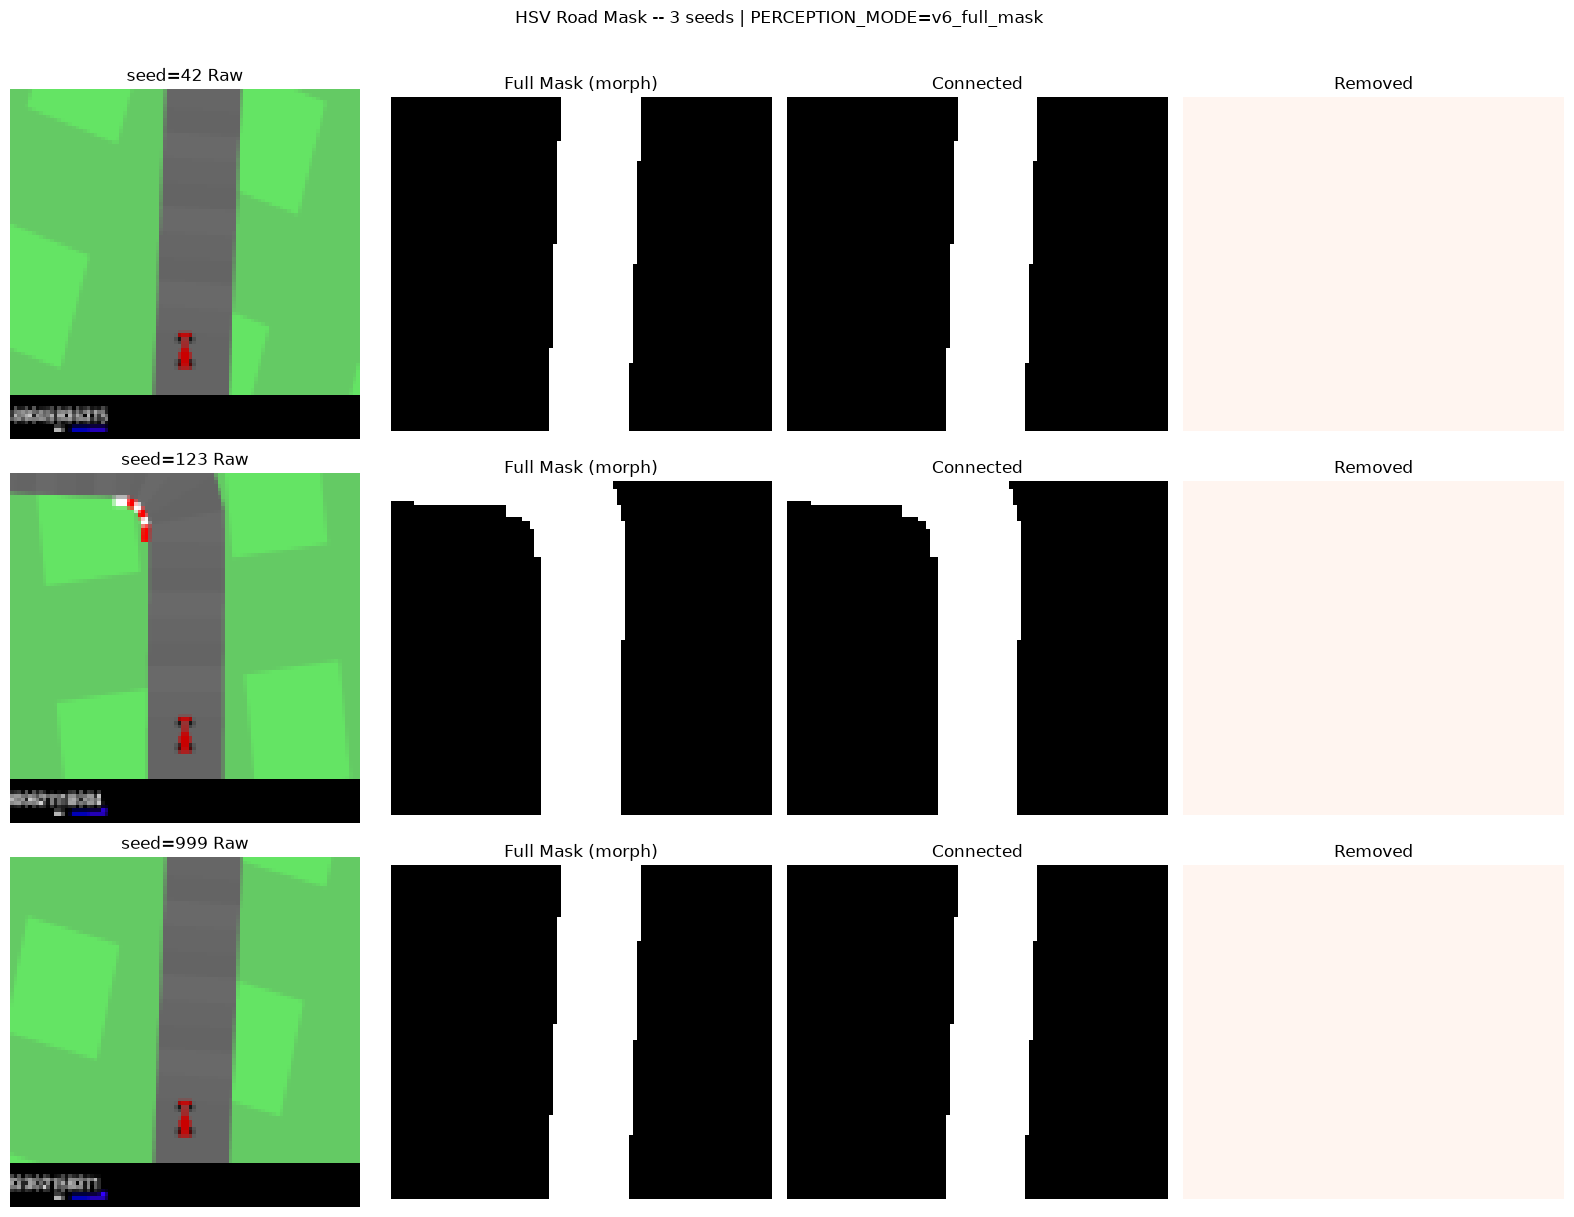


Saved: /content/carracing_ppo_v11_1_sac_fast_result/figures/diag_masks_3seed.png


In [10]:
# Diagnostic: 3-seed HSV mask comparison

print("=" * 60)
print("PERCEPTION DIAGNOSTIC -- 3-SEED MASK COMPARISON")
print(f"Active mode: PERCEPTION_MODE = {PERCEPTION_MODE}")
print(f"V9: 3x3 morphological opening applied by default")
print("Seeds: [42, 123, 999]")
print("=" * 60)

_diag_seeds = [42, 123, 999]
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

_diag_masks_data = {}

for _row, _dseed in enumerate(_diag_seeds):
    _de = gym.make(CAR_RACING_ENV_ID, render_mode="rgb_array",
                   continuous=True, domain_randomize=False)
    _dobs, _ = _de.reset(seed=_dseed)
    for _ in range(60):
        _dobs, _, _, _, _ = _de.step(np.array([0.0, 0.3, 0.0], dtype=np.float32))
    _de.close()

    _draw = _dobs.copy()
    _dfull = road_mask_hsv(_draw)
    _dconn = connected_road_mask(_dfull)
    _ddiff = cv2.absdiff(_dfull, _dconn)

    _diag_masks_data[_dseed] = {"raw": _draw, "full": _dfull, "conn": _dconn}

    axes[_row, 0].imshow(_draw);            axes[_row, 0].set_title(f"seed={_dseed} Raw")
    axes[_row, 1].imshow(_dfull, cmap="gray"); axes[_row, 1].set_title("Full Mask (morph)")
    axes[_row, 2].imshow(_dconn, cmap="gray"); axes[_row, 2].set_title("Connected")
    axes[_row, 3].imshow(_ddiff, cmap="Reds"); axes[_row, 3].set_title("Removed")
    for ax in axes[_row]: ax.axis("off")

    _fp = np.sum(_dfull > 0) / _dfull.size * 100
    _cp = np.sum(_dconn > 0) / _dconn.size * 100
    _rm = _fp - _cp
    print(f"  seed={_dseed}: full={_fp:.1f}%  connected={_cp:.1f}%  removed={_rm:.1f}%")

plt.suptitle(f"HSV Road Mask -- 3 seeds | PERCEPTION_MODE={PERCEPTION_MODE}", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/diag_masks_3seed.png", dpi=100, bbox_inches="tight")
_backup(f"{FIG_DIR}/diag_masks_3seed.png")
plt.show()
print(f"\nSaved: {FIG_DIR}/diag_masks_3seed.png")


### Figure Explanation: HSV Road Mask (`diag_masks_3seed.png`)

**Question:** Does the HSV color filter reliably detect the drivable road surface across different random seeds?

**How to read it:** Each row = one seed (42, 123, 999). Columns: (1) raw RGB frame, (2) full HSV mask — pixels classified as road, (3) connected-component mask — road region connected to the car, (4) removed pixels — excluded by the connected filter.

**Good result:** Road pixels clearly detected, minimal noise. Connected mask covers the road ahead. Removed pixels small or absent.

**V9 shows:** All three seeds show clean road detection. The 3×3 morphological opening (MORPH_OPEN) reduces noise without eroding narrow road segments.

**Report placement:** Supplemental appendix — perception design documentation, not a performance result.

RADAR DIAGNOSTIC -- 3-SEED COMPARISON
Seeds: [42, 123, 999]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


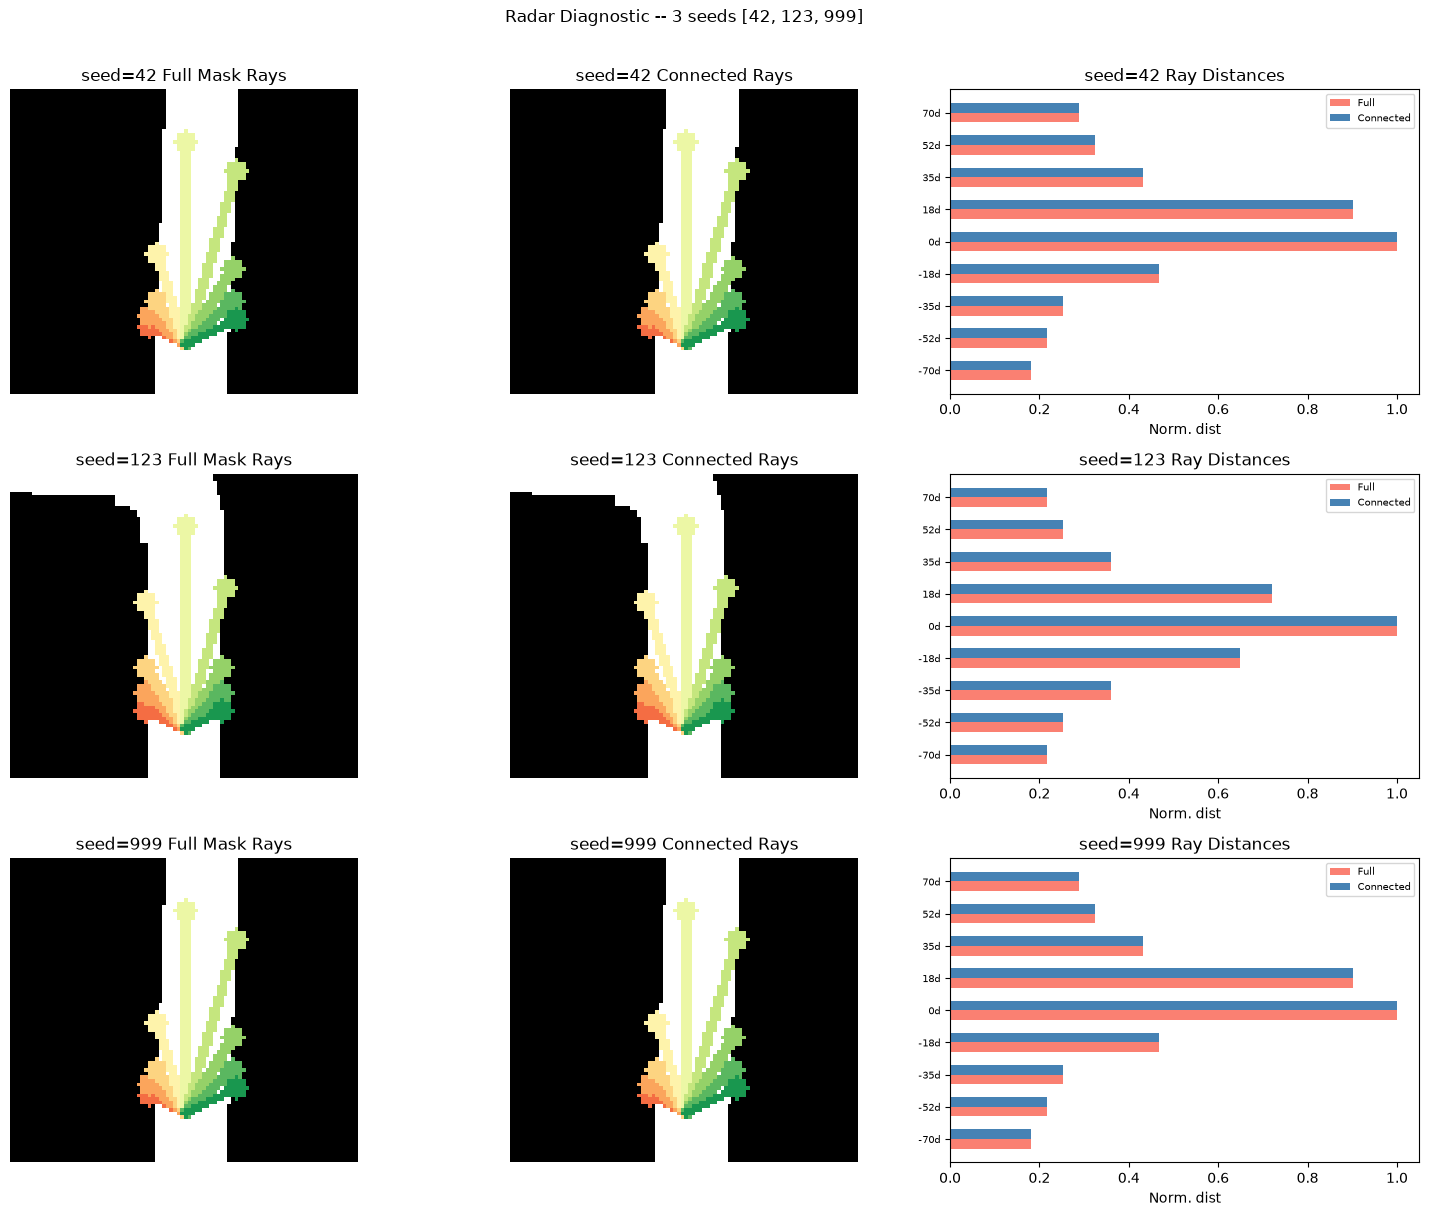


Saved: /content/carracing_ppo_v11_1_sac_fast_result/figures/diag_radar_3seed.png

-- 16D Observation Vector (seed=42) --
Active observation source: full mask
Feature            Active
--------------------------
ray_-70deg         0.1802
ray_-52deg         0.2162
ray_-35deg         0.2523
ray_-18deg         0.4685
ray_0deg           1.0000
ray_18deg          0.9009
ray_35deg          0.4324
ray_52deg          0.3243
ray_70deg          0.2883
steer              0.0000
gas                0.0000
brake              0.0000
speed              0.3000
curve              0.0000
front_delta        0.0000
lr_asym            0.0000


In [11]:
# Diagnostic: 3-seed radar overlay + 16D obs table

print("=" * 60)
print("RADAR DIAGNOSTIC -- 3-SEED COMPARISON")
print("Seeds: [42, 123, 999]")
print("=" * 60)

_diag_seeds_r = [42, 123, 999]
_speed_diag = 0.3
_spd = float(np.clip(_speed_diag, 0.0, 1.0))
_max_len = 45.0 + _spd * 35.0
_squeeze = 1.0 - _spd * 0.18
_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 9))
_ox, _oy = RAY_ORIGIN

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for _row, _dseed in enumerate(_diag_seeds_r):
    if "_diag_masks_data" in dir() and _dseed in _diag_masks_data:
        _draw = _diag_masks_data[_dseed]["raw"]
        _dfull = _diag_masks_data[_dseed]["full"]
        _dconn = _diag_masks_data[_dseed]["conn"]
    else:
        _de = gym.make(CAR_RACING_ENV_ID, render_mode="rgb_array",
                       continuous=True, domain_randomize=False)
        _dobs, _ = _de.reset(seed=_dseed)
        for _ in range(60):
            _dobs, _, _, _, _ = _de.step(np.array([0.0, 0.3, 0.0], dtype=np.float32))
        _de.close()
        _draw = _dobs.copy()
        _dfull = road_mask_hsv(_draw)
        _dconn = connected_road_mask(_dfull)

    _rays_full = compute_rays_dynamic(_dfull, prev_speed=_speed_diag)
    _rays_conn = compute_rays_dynamic(_dconn, prev_speed=_speed_diag)

    for ax, mask, rays, col_title in [
        (axes[_row, 0], _dfull, _rays_full, "Full Mask Rays"),
        (axes[_row, 1], _dconn, _rays_conn, "Connected Rays"),
    ]:
        overlay = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
        for i, angle in enumerate(RAY_ANGLES_DEG * _squeeze):
            rad = np.deg2rad(float(angle))
            dx, dy = np.sin(rad), -np.cos(rad)
            dist = rays[i] * _max_len
            ex, ey = int(_ox + dx * dist), int(_oy + dy * dist)
            c = tuple(int(255*x) for x in _colors[i][:3])
            cv2.line(overlay, (_ox, _oy), (ex, ey), c, 2)
            cv2.circle(overlay, (ex, ey), 3, c, -1)
        ax.imshow(overlay); ax.set_title(f"seed={_dseed} {col_title}"); ax.axis("off")

    x = np.arange(9)
    axes[_row, 2].barh(x - 0.15, _rays_full, 0.3, color="salmon", label="Full")
    axes[_row, 2].barh(x + 0.15, _rays_conn, 0.3, color="steelblue", label="Connected")
    axes[_row, 2].set_yticks(x)
    axes[_row, 2].set_yticklabels([f"{a:.0f}d" for a in RAY_ANGLES_DEG], fontsize=7)
    axes[_row, 2].set_xlabel("Norm. dist")
    axes[_row, 2].set_title(f"seed={_dseed} Ray Distances")
    axes[_row, 2].legend(fontsize=7)

plt.suptitle("Radar Diagnostic -- 3 seeds [42, 123, 999]", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/diag_radar_3seed.png", dpi=100, bbox_inches="tight")
_backup(f"{FIG_DIR}/diag_radar_3seed.png")
plt.show()
print(f"\nSaved: {FIG_DIR}/diag_radar_3seed.png")

# 16D obs table -- seed 42
if "_diag_masks_data" in dir() and 42 in _diag_masks_data:
    _dfull42 = _diag_masks_data[42]["full"]
    _dconn42 = _diag_masks_data[42]["conn"]
else:
    _dfull42 = _dfull; _dconn42 = _dconn
_rays_f42 = compute_rays_dynamic(_dfull42, prev_speed=_speed_diag)
_rays_c42 = compute_rays_dynamic(_dconn42, prev_speed=_speed_diag)
_active_rays42 = _rays_f42 if PERCEPTION_MODE == "v6_full_mask" else _rays_c42
_active_src = "full mask" if PERCEPTION_MODE == "v6_full_mask" else "connected mask"
_obs_16d = np.concatenate([_active_rays42, [0., 0., 0., _speed_diag, 0., 0., 0.]])
_labels = ([f"ray_{a:.0f}deg" for a in RAY_ANGLES_DEG] +
           ["steer", "gas", "brake", "speed", "curve", "front_delta", "lr_asym"])
print(f"\n-- 16D Observation Vector (seed=42) --")
print(f"Active observation source: {_active_src}")
print(f"{'Feature':<14s} {'Active':>10s}")
print("-" * 26)
for lbl, val in zip(_labels, _obs_16d):
    print(f"{lbl:<14s} {val:10.4f}")


### Figure Explanation: Radar-Like Ray Distances (`diag_radar_3seed.png`)

**Question:** Do the 9 radar-like rays correctly measure drivable road distance per direction? Do different seeds produce meaningfully different patterns?

**How to read it:** Each row = one seed. Left panels show rays overlaid on the road mask. Right panels show a bar chart of ray distances per angle (−70° to +70°). Longer bars = more visible drivable road in that direction.

**Good result:** Clear directional variation in ray distances. Different seeds show different patterns — confirms the observation captures track-specific geometry.

**V9 shows:** Seeds 42, 123, and 999 show distinct road curvature profiles, supporting the claim that the 16D observation carries track-specific information.

**Report placement:** Supplemental appendix — perception design documentation.

> **Note:** These are mask-based ray estimates, not physical radar. Each ray is cast on the road mask image and reports how far it can travel before hitting a non-road pixel.

ACTION SMOOTHING + REWARD COMPONENTS
EMA_ALPHA=0.4 (V9: more responsive than V8.2 at 0.65)


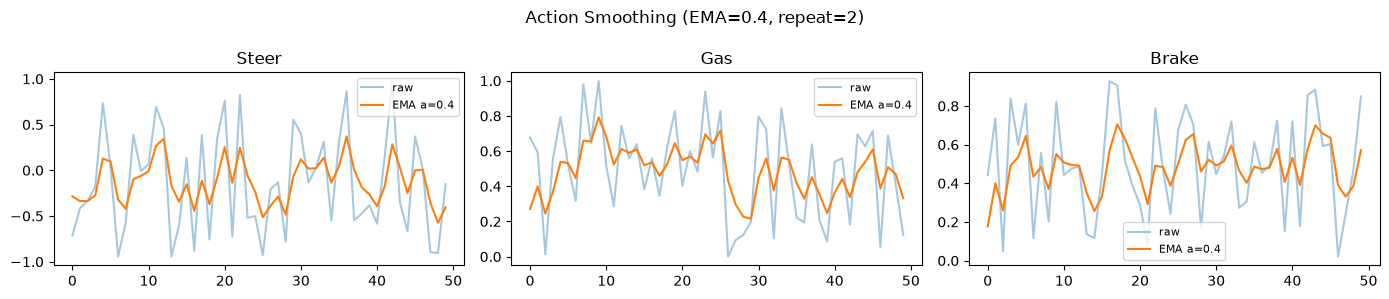

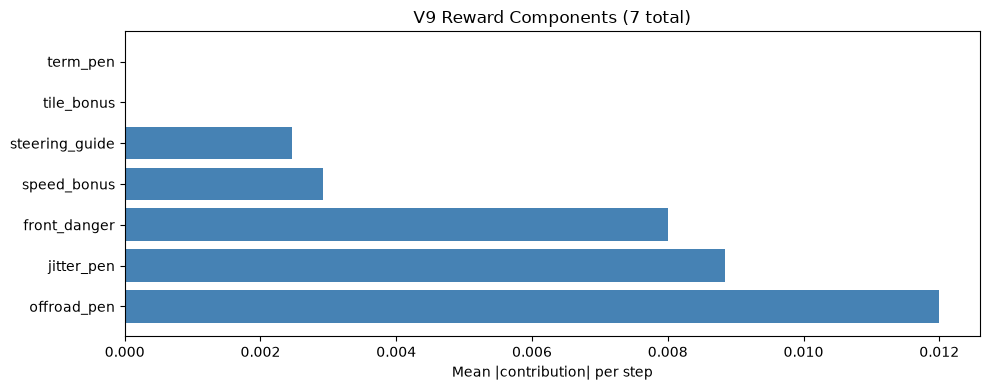


-- Reward Components --
  offroad_pen          0.0120
  jitter_pen           0.0088
  front_danger         0.0080
  speed_bonus          0.0029
  steering_guide       0.0025
  tile_bonus           0.0000
  term_pen             0.0000


In [12]:
# Diagnostic: Action smoothing + reward breakdown

print("=" * 60)
print("ACTION SMOOTHING + REWARD COMPONENTS")
print(f"EMA_ALPHA={EMA_ALPHA}")
print("=" * 60)

_base = gym.make(CAR_RACING_ENV_ID, continuous=True, domain_randomize=False)
_w = CarRacingWrapper(_base)
_w.reset(seed=SEED)
_rb_accum, _raw_a, _smo_a = {}, [], []

for _ in range(50):
    a = _w.action_space.sample()
    _raw_a.append(a.copy())
    _, _, t, tr, info = _w.step(a)
    _smo_a.append(_w._smoothed.copy())
    for k, v in info.get("reward_breakdown", {}).items():
        _rb_accum.setdefault(k, []).append(v)
    if t or tr: _w.reset()
_w.close()

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
_ra, _sa = np.array(_raw_a), np.array(_smo_a)
for i, name in enumerate(["Steer", "Gas", "Brake"]):
    axes[i].plot(_ra[:,i], alpha=0.4, label="raw")
    axes[i].plot(_sa[:,i], label=f"EMA a={EMA_ALPHA}")
    axes[i].set_title(name); axes[i].legend(fontsize=8)
plt.suptitle(f"Action Smoothing (EMA={EMA_ALPHA}, repeat={ACTION_REPEAT})")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/diag_action_smoothing.png", dpi=120)
_backup(f"{FIG_DIR}/diag_action_smoothing.png")
plt.show()

if _rb_accum:
    _rb_means = sorted([(k, np.mean(np.abs(v))) for k, v in _rb_accum.items()], key=lambda x: -x[1])
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh([k for k,_ in _rb_means], [v for _,v in _rb_means], color='steelblue')
    ax.set_xlabel("Mean |contribution| per step")
    ax.set_title("V9 Reward Components (7 total)")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/diag_reward_breakdown.png", dpi=120)
    _backup(f"{FIG_DIR}/diag_reward_breakdown.png")
    plt.show()
    print("\n-- Reward Components --")
    for k, v in _rb_means: print(f"  {k:<20s} {v:.4f}")


### Figure Explanations: Action Smoothing and Reward Breakdown

**`diag_action_smoothing.png`**

**Question:** How much does EMA smoothing (α=0.40) affect raw policy actions?

**How to read it:** Three subplots (steer / gas / brake). Each shows raw policy output vs EMA-smoothed action over 50 random steps. Closer curves = lighter smoothing. V9 uses α=0.40 (more responsive than the earlier α=0.65).

**Report placement:** Archive only — internal debugging reference.

---

**`diag_reward_breakdown.png`**

**Question:** What are the relative magnitudes of the 7 reward shaping components?

**How to read it:** Horizontal bar chart. Each bar = mean absolute magnitude of one reward component per step: `tile_bonus`, `steering_guide`, `speed_bonus`, `front_danger`, `jitter_pen`, `offroad_pen`, `term_pen`. Longer bar = larger average contribution.

**What this is:** Bars come from a 50-step random-action diagnostic sample (`action_space.sample()`), **not the trained policy**. Expected in this diagnostic: `tile_bonus = 0` because random driving makes no tile progress, while `offroad_pen`, `jitter_pen`, and `front_danger` may dominate. This is a reward-component plumbing and scale check — it confirms all 7 components are wired and firing, not the trained policy's final reward decomposition.

**Report placement:** Supplemental appendix — reward design justification.

> **Important:** This shows component *magnitude* under random actions, not *causation*. It does not prove any single component caused V9's improvement.

## Smoke Tests

**Purpose:** Verify that all environment shapes, PPO construction, and seed isolation are correct before any training.

**Consumes:** All cells above (config, perception, wrapper, VecEnv, eval helpers).

**Produces:** Printed PASS/FAIL results. No files saved.

**Success looks like:** `VecEnv: OK train=(4,64)`, `SAC build + predict: PASS`, `SEED ISOLATION: ALL 3 LAYERS PASSED`.

**Report relevance:** None — pre-flight checks only.

In [13]:
# Smoke test: raw env + wrapper + VecEnv

# Raw env
_e = gym.make(CAR_RACING_ENV_ID, render_mode="rgb_array", continuous=True, domain_randomize=False)
_obs, _ = _e.reset(seed=0)
assert _obs.shape == (96, 96, 3)
_e.close()
print("Raw env: OK")

# Wrapper
_base = gym.make(CAR_RACING_ENV_ID, continuous=True, domain_randomize=False)
_w = CarRacingWrapper(_base)
check_env(_w, warn=True)
_obs, _ = _w.reset(seed=SEED)
assert _obs.shape == (OBS_DIM_BASE,), f"obs {_obs.shape} != ({OBS_DIM_BASE},)"
assert np.all(np.isfinite(_obs))
for i in range(10):
    _obs, _r, _t, _tr, _info = _w.step(_w.action_space.sample())
    assert _obs.shape == (OBS_DIM_BASE,) and np.all(np.isfinite(_obs))
    if _t or _tr: _w.reset()
_w.close()
print(f"Wrapper: OK  obs=({OBS_DIM_BASE},)  action=(3,)")

# VecEnv
_tv = build_train_vec()
_obs = _tv.reset()
assert _obs.shape == (_tv.num_envs, OBS_DIM_STACKED), f"train {_obs.shape}"
assert np.all(np.isfinite(_obs))
_tv.close()
print(f"VecEnv: OK  train=({_tv.num_envs},{OBS_DIM_STACKED})")


Raw env: OK
Wrapper: OK  obs=(16,)  action=(3,)
VecEnv: OK  train=(1,64)


In [14]:
# Smoke test: SAC build + predict + config verify

train_vec = build_train_vec()
eval_vec  = build_eval_vec(seed=999)

model = SAC(
    "MlpPolicy", train_vec,
    learning_rate=SAC_LR_CONSTANT,
    buffer_size=BUFFER_SIZE, learning_starts=LEARNING_STARTS,
    batch_size=SAC_BATCH_SIZE, tau=TAU, gamma=GAMMA,
    train_freq=TRAIN_FREQ, gradient_steps=GRADIENT_STEPS,
    ent_coef=SAC_ENT_COEF, target_entropy=TARGET_ENTROPY,
    use_sde=USE_SDE,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=1, seed=SEED, device=DEVICE,
)

_params = sum(p.numel() for p in model.policy.parameters())
_obs = train_vec.reset()
_act, _ = model.predict(_obs, deterministic=True)
assert _act.shape == (train_vec.num_envs, 3) and np.all(np.isfinite(_act)), \
    f"SAC predict shape/finite check failed: {_act.shape}"

model.save(f"{LOG_DIR}/_smoke_test_model")
_smoke_model = SAC.load(f"{LOG_DIR}/_smoke_test_model")  # NO env=
_smoke_act, _ = _smoke_model.predict(_obs, deterministic=True)
assert _smoke_act.shape == (train_vec.num_envs, 3), "SAC.load without env must still predict correctly"
os.remove(f"{LOG_DIR}/_smoke_test_model.zip")
del _smoke_model

assert model.use_sde == USE_SDE
assert model.buffer_size == BUFFER_SIZE
assert model.learning_starts == LEARNING_STARTS
assert model.batch_size == SAC_BATCH_SIZE

print(f"SAC: params={_params:,}  device={DEVICE}")
print(f"USE_SDE={model.use_sde}  BUFFER={model.buffer_size}  LEARNING_STARTS={model.learning_starts}")
print(f"SAC.load without env: OK (predict works)")

# --- SMOKE round-trip: model + VecNormalize + replay buffer save/load ----------
# Verifies the exact artifacts Stage 3 / official runs depend on, WITHOUT training.
# (No model.learn() here -- the replay buffer is empty, this is a plumbing check.)
# ponytail: save_replay_buffer writes the full preallocated buffer (~buffer_size x
#           obs); fine as a one-off smoke check, not in any training loop.
import tempfile as _tf, shutil as _sh
from stable_baselines3.common.vec_env import VecNormalize as _VN
_smoke_dir = _tf.mkdtemp(prefix="v10_smoke_", dir=LOG_DIR)
try:
    _mp = f"{_smoke_dir}/sac_model"
    model.save(_mp)
    assert os.path.isfile(_mp + ".zip"), "SAC model .zip not saved"
    _m2 = SAC.load(_mp)  # NO env=
    _a2, _ = _m2.predict(_obs, deterministic=True)
    assert _a2.shape == (train_vec.num_envs, 3), "reloaded SAC model predict shape wrong"

    _vnp = f"{_smoke_dir}/vecnorm.pkl"
    train_vec.save(_vnp)
    assert os.path.isfile(_vnp), "VecNormalize .pkl not saved"
    _vn2 = _VN.load(_vnp, train_vec.venv)
    assert hasattr(_vn2, "obs_rms"), "VecNormalize reload failed"

    _rbp = f"{_smoke_dir}/replay_buffer.pkl"
    model.save_replay_buffer(_rbp)
    assert os.path.isfile(_rbp), "replay buffer .pkl not saved"
    model.load_replay_buffer(_rbp)  # must not crash

    print("Round-trip: SAC model + VecNormalize + replay buffer save/load OK")
finally:
    _sh.rmtree(_smoke_dir, ignore_errors=True)

print("\nSAC build + predict + save/load round-trip: PASS")


Using cuda device
SAC: params=417,802  device=cuda
USE_SDE=False  BUFFER=200000  LEARNING_STARTS=10000
SAC.load without env: OK (predict works)
Round-trip: SAC model + VecNormalize + replay buffer save/load OK

SAC build + predict + save/load round-trip: PASS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
# Three-layer seed isolation self-test

print("=" * 60)
print("SEED ISOLATION TEST (3-layer)")
print("=" * 60)

_test_seeds = [42, 123, 999]
_seed_test_passed = False

print("\nLayer 1: Raw Gymnasium env")
_raw_hashes = []
for s in _test_seeds:
    _e = gym.make(CAR_RACING_ENV_ID, render_mode="rgb_array",
                  continuous=True, domain_randomize=False)
    _e.reset(seed=s)
    _frame = _e.render()
    h = _hash_array(_frame)
    _raw_hashes.append(h)
    print(f"  seed={s:>5d}  raw_hash={h}")
    _e.close()
assert len(set(_raw_hashes)) == len(_test_seeds), \
    f"Layer 1 FAILED: raw gym hashes not unique: {_raw_hashes}"
print("  Layer 1: PASS")

print("\nLayer 2: Wrapped env (16D features)")
_wrap_hashes = []
for s in _test_seeds:
    _e = gym.make(CAR_RACING_ENV_ID, render_mode="rgb_array",
                  continuous=True, domain_randomize=False)
    _w = CarRacingWrapper(_e)
    _obs, _ = _w.reset(seed=s)
    _frame = _w.render()
    h = _hash_array(_frame)
    _wrap_hashes.append(h)
    print(f"  seed={s:>5d}  wrap_hash={h}  obs[:3]={_obs[:3]}")
    _w.close()
assert len(set(_wrap_hashes)) == len(_test_seeds), \
    f"Layer 2 FAILED: wrapped hashes not unique: {_wrap_hashes}"
print("  Layer 2: PASS")

print("\nLayer 3: Smoke eval path (fresh VecNorm + SAC.load without env)")
_eval_hashes = []
for s in _test_seeds:
    _tv = build_eval_vec(seed=s)
    _obs = _tv.reset()
    h = _first_frame_hash(_tv)
    _eval_hashes.append(h)
    print(f"  seed={s:>5d}  eval_hash={h}")
    _tv.close()
assert len(set(_eval_hashes)) == len(_test_seeds), \
    f"Layer 3 FAILED: eval path hashes not unique: {_eval_hashes}"
print("  Layer 3: PASS")

_seed_test_passed = True
print(f"\nSEED ISOLATION: ALL 3 LAYERS PASSED")


SEED ISOLATION TEST (3-layer)

Layer 1: Raw Gymnasium env
  seed=   42  raw_hash=d54c877f15a9
  seed=  123  raw_hash=a3546d564073
  seed=  999  raw_hash=bf134fc86169
  Layer 1: PASS

Layer 2: Wrapped env (16D features)
  seed=   42  wrap_hash=d54c877f15a9  obs[:3]=[0. 0. 0.]
  seed=  123  wrap_hash=a3546d564073  obs[:3]=[0. 0. 0.]
  seed=  999  wrap_hash=bf134fc86169  obs[:3]=[0. 0. 0.]
  Layer 2: PASS

Layer 3: Smoke eval path (fresh VecNorm + SAC.load without env)
  seed=   42  eval_hash=d54c877f15a9
  seed=  123  eval_hash=a3546d564073
  seed=  999  eval_hash=bf134fc86169
  Layer 3: PASS

SEED ISOLATION: ALL 3 LAYERS PASSED


In [16]:
# Configuration audit + SMOKE_ONLY banner

_config_audited = False

print("=" * 60)
print("CONFIGURATION AUDIT (SAC)")
print("=" * 60)

print(f"\n  RUN_MODE:          {RUN_MODE}")
print(f"  PERCEPTION_MODE:   {PERCEPTION_MODE}")
print(f"  N_ENVS:            {N_ENVS}")
print(f"  USE_SDE:           {USE_SDE}")
print(f"  ENT_COEF:          {SAC_ENT_COEF} (adaptive)")
print(f"  TOTAL_TIMESTEPS:   {TOTAL_TIMESTEPS:,}")
print(f"  BUFFER_SIZE:       {BUFFER_SIZE}")
print(f"  LEARNING_STARTS:   {LEARNING_STARTS}")
print(f"  BATCH_SIZE:        {SAC_BATCH_SIZE}")
print(f"  EMA_ALPHA:         {EMA_ALPHA}")
print(f"  OFFROAD_PEN:       {OFFROAD_PEN}")
print(f"  OBS_DIM_BASE:      {OBS_DIM_BASE}")
# --- V11 vectorization + update-to-data-ratio audit (proves realized UTD) ------
_eff_n = resolve_nenvs()
_grad_per_cycle = _eff_n  # gradient_steps=-1 with train_freq=(1,"step") => N_ENVS updates/cycle
_utd = _grad_per_cycle / _eff_n  # = 1.0 by construction
print("  -- V11 vectorization / UTD --")
print(f"  N_ENVS (effective):  {_eff_n}   (target={N_ENVS}, USE_SUBPROC={USE_SUBPROC})")
print(f"  vec env class:       {'SubprocVecEnv' if _eff_n > 1 else 'DummyVecEnv'}")
print(f"  train_freq:          {TRAIN_FREQ}")
print(f"  gradient_steps:      {GRADIENT_STEPS}   (-1 => one update per env step collected this cycle)")
print(f"  transitions/cycle:   {_eff_n}")
print(f"  grad updates/cycle:  {_grad_per_cycle}")
print(f"  estimated UTD:       {_utd:.2f}   (updates / transitions)")
print("  -- V11.1 FAST_RESULT update density --")
print(f"  SPEED_MODE:          {SPEED_MODE}")
print(f"  train_freq:          {TRAIN_FREQ}   gradient_steps: {GRADIENT_STEPS} (FIXED)")
print(f"  transitions/cycle:   {TRAIN_FREQ[0]}   updates/cycle: {GRADIENT_STEPS}")
print(f"  UPDATE_DENSITY:      {UPDATE_DENSITY:.3f} updates/env-step  ({DISCLOSURE_LABEL})")
if UPDATE_DENSITY < 1.0:
    print("  [DISCLOSURE] FAST_RESULT/AGGRESSIVE reduce SAC update density (UTD<1) ->")
    print("              NOT strictly gradient-compute-comparable to the V11 UTD=1 branch.")
print(f"  total grad updates at {TOTAL_TIMESTEPS:,} env steps (UTD=1): ~{TOTAL_TIMESTEPS:,}")
print("  (wall-clock / fps / total-updates are also printed live by the ETA + SB3 logger during training)")
# --- SAC replay-buffer RAM visibility (off-policy buffers are large) ----------
try:
    import psutil as _ps
    _avail_gb = _ps.virtual_memory().available / 1e9
    _rb_gb = (BUFFER_SIZE * OBS_DIM_STACKED * 4 * 2) / 1e9  # obs+next_obs float32 est.
    print(f"  RAM available:     {_avail_gb:.1f} GB")
    print(f"  SAC buffer_size:   {BUFFER_SIZE:,}  (~{_rb_gb:.2f} GB obs est. @ {OBS_DIM_STACKED}D f32)")
    if _avail_gb < 2.5:
        print("  [!] Low RAM (<2.5 GB). Consider BUFFER_SIZE=100_000 before a long run.")
except Exception as _ram_e:
    print(f"  RAM check skipped (psutil unavailable: {_ram_e}). SAC buffer_size={BUFFER_SIZE:,}")
print(f"  Seed test passed:  {_seed_test_passed}")

_comparability = "V9-INTEGRATED"
print(f"\n  Comparability: {_comparability}")
print("  V9 is an integrated redesign. Perception, reward, and training profile were co-designed (no per-change ablation here).")
print("  Individual changes cannot be attributed without ablation studies.")

if _IS_RAPID:
    print(f"\n  Target directory: {RAPID_DIR}")
    print(f"  Rapid timesteps:  {RAPID_TIMESTEPS:,}")
elif _IS_OFFICIAL:
    print(f"\n  Target directory: {OFFICIAL_DIR}")
    print(f"  Eval freq:        every {EVAL_FREQ * N_ENVS:,} steps")
    print(f"  Ckpt freq:        every {CKPT_FREQ * N_ENVS:,} steps")

_config_audited = True

print("\n" + "=" * 60)
print("OBSERVATION STACK / MLP INPUT")
print("=" * 60)
print(f"  Base obs: {OBS_DIM_BASE}D per frame")
print( "    9 radar rays (normalized road distance per angle)")
print( "    + steer + gas + brake (EMA-smoothed actions)")
print( "    + speed + curvature")
print( "    + front_ray_delta (V9 new)")
print( "    + left_right_asymmetry (V9 new)")
print(f"  Stack:    {N_STACK} frames  (t-3, t-2, t-1, t)")
print(f"  MLP in:   {OBS_DIM_STACKED}D = {OBS_DIM_BASE}D x {N_STACK}")
print( "  Policy:   MlpPolicy [256, 256]")
print("=" * 60)

print()
if RUN_MODE == "SMOKE_ONLY":
    _mask_ok = os.path.isfile(f"{FIG_DIR}/diag_masks_3seed.png")
    _radar_ok = os.path.isfile(f"{FIG_DIR}/diag_radar_3seed.png")
    if _mask_ok and _radar_ok: _s1 = "[OK]"
    elif _mask_ok or _radar_ok: _s1 = "[PARTIAL]"
    else: _s1 = "[MISSING]"
    _s2 = "[OK]" if _seed_test_passed else "[FAIL]"
    _s3 = "[OK]"
    _s4 = "[OK]" if _config_audited else "[FAIL]"
    print("=" * 51)
    print("SMOKE_ONLY COMPLETE")
    print(f"  {_s1} 3-seed perception diagnostics: mask + radar")
    print(f"  {_s2} Seed isolation (3-layer hashes unique)")
    print(f"  {_s3} Observation + SAC shapes correct")
    print(f"  {_s4} Config audit passed (SAC profile)")
    print("=" * 51)
    print("Training is complete. To re-run evaluation, set RUN_MODE to EVAL_ONLY."
           " Do not re-run OFFICIAL_500K unless intentionally starting a new training run.")
    print("=" * 51)
elif _IS_RAPID:
    print("Config audit passed. Ready for RAPID_50K (next cell).")
elif _IS_OFFICIAL:
    print("Config audit passed. Ready for OFFICIAL_500K.")
elif RUN_MODE == "EVAL_ONLY":
    print("Config audit passed. Ready for evaluation.")
elif RUN_MODE == "RESUME":
    print("Config audit passed.")


CONFIGURATION AUDIT (V11 SAC)

  RUN_MODE:          SMOKE_ONLY
  PERCEPTION_MODE:   v6_full_mask
  N_ENVS:            1
  USE_SDE:           False
  ENT_COEF:          auto (adaptive)
  TOTAL_TIMESTEPS:   500,000
  BUFFER_SIZE:       200000
  LEARNING_STARTS:   10000
  BATCH_SIZE:        256
  EMA_ALPHA:         0.4
  OFFROAD_PEN:       0.3
  OBS_DIM_BASE:      16
  -- V11 vectorization / UTD --
  N_ENVS (effective):  1   (target=1, USE_SUBPROC=False)
  vec env class:       DummyVecEnv
  train_freq:          (4, 'step')
  gradient_steps:      1   (-1 => one update per env step collected this cycle)
  transitions/cycle:   1
  grad updates/cycle:  1
  estimated UTD:       1.00   (updates / transitions)
  -- V11.1 FAST_RESULT update density --
  SPEED_MODE:          FAST_RESULT
  train_freq:          (4, 'step')   gradient_steps: 1 (FIXED)
  transitions/cycle:   4   updates/cycle: 1
  UPDATE_DENSITY:      0.250 updates/env-step  (fast-result (default): 1 update / 4 env steps)
  [DISCLOSUR

## Model and Training Protocol

**Purpose:** Run PPO training in two phases: a 50k rapid validation gate to confirm the run is healthy, then the official 500k training run.

**Consumes:** Config (Cell 3), PPO model (Cell 17), callbacks (Cell 8).

**Produces:** `best_model.zip`, `model_final.zip`, paired VecNormalize `.pkl` files, `evaluations.npz`, `ckpt_inventory.csv`.

**Success looks like (SAC, post-warmup):** Rapid gate returns CONTINUE when the last eval > 100 with a positive recent trend and diagnostics OK; DIAGNOSE for weak/suspicious runs; STOP on collapse / NaN / very low reward.

> **SAC note:** learning starts at `LEARNING_STARTS=5000`, so early reward may lag PPO. If the 50k result is borderline, inspect `ent_coef`, `actor_loss`, `critic_loss`, the trend, and failure indicators before deciding. Do not expect PPO-style >150-at-50k.

**Report relevance:** High — `evaluations.npz` is the source for the training curve (primary result figure).

> **Note:** Training is already complete. Cell 21 (Rapid 50k) and Cell 23 (OFFICIAL\_500K) outputs have been cleared in this clean version. Full training logs are in `evidence_logs/V9_training_500k_log.txt`.

In [18]:
# === OPTIONAL TRAINING CELL - DISABLED BY DEFAULT (REPORT_ONLY) ===
# This final notebook ships in REPORT_ONLY / EVAL_ONLY mode. Training is
# long-running and is NOT required to reproduce the reported results from
# the saved artifacts. To actually train, set ALLOW_TRAINING = True in the
# Configuration cell, then re-run this cell.
if globals().get('ALLOW_TRAINING', False):
    # Rapid validation run (50k steps)

    assert _IS_RAPID, f"RUN_MODE={RUN_MODE}. Set to RAPID_50K."
    assert _seed_test_passed, "Run seed isolation test first."
    assert _config_audited, "Run config audit first."

    print("=" * 60)
    print("RAPID VALIDATION RUN (V11 SAC)")
    print(f"BUFFER={BUFFER_SIZE} LEARNING_STARTS={LEARNING_STARTS} BATCH={SAC_BATCH_SIZE}")
    print("This is a validation gate, not a benchmark.")
    print("=" * 60)

    _rapid_ckpt = f"{RAPID_DIR}/checkpoints"
    _rapid_best = f"{RAPID_DIR}/best"
    os.makedirs(_rapid_ckpt, exist_ok=True)
    os.makedirs(_rapid_best, exist_ok=True)

    rapid_train_vec = build_train_vec()
    rapid_eval_vec  = build_eval_vec(seed=999)

    rapid_model = SAC(
        "MlpPolicy", rapid_train_vec,
        learning_rate=SAC_LR_CONSTANT,
        buffer_size=BUFFER_SIZE, learning_starts=LEARNING_STARTS,
        batch_size=SAC_BATCH_SIZE, tau=TAU, gamma=GAMMA,
        train_freq=TRAIN_FREQ, gradient_steps=GRADIENT_STEPS,
        ent_coef=SAC_ENT_COEF, target_entropy=TARGET_ENTROPY,
        use_sde=USE_SDE,
        policy_kwargs=dict(net_arch=[256, 256]),
        verbose=1, seed=SEED, device=DEVICE,
    )

    rapid_cbs = make_callbacks(
        rapid_train_vec, rapid_eval_vec,
        ckpt_dir=_rapid_ckpt, best_dir=_rapid_best,
        log_dir=LOG_DIR, eval_freq=RAPID_EVAL_FREQ, ckpt_freq=RAPID_CKPT_FREQ,
        prefix="rapid", total_ts=RAPID_TIMESTEPS,
    )

    print(f"\nTraining {RAPID_TIMESTEPS:,} steps (rapid validation)")

    _rapid_cfg = {
        "notebook": "V11_CarRacing_SAC_Main.ipynb",
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "RUN_MODE": RUN_MODE,
        "PERCEPTION_MODE": PERCEPTION_MODE,
        "SEED": SEED, "N_ENVS_TARGET": N_ENVS, "N_ENVS_EFFECTIVE": resolve_nenvs(),
        "ALGORITHM": "SAC",
        "USE_SDE": USE_SDE,
        "BUFFER_SIZE": BUFFER_SIZE, "LEARNING_STARTS": LEARNING_STARTS,
        "SAC_BATCH_SIZE": SAC_BATCH_SIZE, "TAU": TAU,
        "TRAIN_FREQ": list(TRAIN_FREQ), "GRADIENT_STEPS": GRADIENT_STEPS,
        "SAC_ENT_COEF": SAC_ENT_COEF, "TARGET_ENTROPY": TARGET_ENTROPY,
        "LEARNING_RATE": LEARNING_RATE,
        "OBS_DIM_BASE": OBS_DIM_BASE, "OBS_DIM_STACKED": OBS_DIM_STACKED,
        "ACTION_DIM": 3, "N_STACK": N_STACK,
        "EMA_ALPHA": EMA_ALPHA, "OFFROAD_PEN": OFFROAD_PEN,
        "RAPID_TIMESTEPS": RAPID_TIMESTEPS,
        "RAPID_EVAL_FREQ_STEPS": RAPID_EVAL_FREQ * N_ENVS,
        "COMPARE5_SEEDS": COMPARE5_SEEDS,
        "RANDOM10_MASTER_SEED": RANDOM10_MASTER_SEED,
        "RANDOM10_COUNT": RANDOM10_COUNT,
        "RAPID_DIR": RAPID_DIR, "LOG_DIR": LOG_DIR,
    }
    _rapid_cfg_path = f"{_rapid_ckpt}/rapid_config.json"
    with open(_rapid_cfg_path, "w") as _f:
        json.dump(_rapid_cfg, _f, indent=2)
    _backup(_rapid_cfg_path)

    _t0 = time.time()

    try:
        rapid_model.learn(total_timesteps=RAPID_TIMESTEPS, reset_num_timesteps=True,
                          progress_bar=True, callback=rapid_cbs)
    except KeyboardInterrupt:
        print("\n[INTERRUPTED]")

    _wall = time.time() - _t0

    rapid_model.save(f"{_rapid_ckpt}/model_rapid_final")
    rapid_train_vec.save(f"{_rapid_ckpt}/vecnorm_rapid_final.pkl")
    if hasattr(rapid_model, "save_replay_buffer"):
        try:
            rapid_model.save_replay_buffer(f"{_rapid_ckpt}/replay_buffer_rapid_final.pkl")
            _backup(f"{_rapid_ckpt}/replay_buffer_rapid_final.pkl")
        except Exception as _e:
            print(f"[WARN] rapid replay buffer save failed: {_e}")

    print(f"\nRapid 50k complete in {_wall:.0f}s ({_wall/60:.1f} min)")
    print(f"  Best:  {_rapid_best}/best_model.zip ({_kb(_rapid_best+'/best_model.zip'):.0f} KB)")
    print(f"  Final: {_rapid_ckpt}/model_rapid_final.zip")
else:
    print('[SKIP] Training disabled (ALLOW_TRAINING=False). Final notebook is in REPORT_ONLY mode.')


Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

RAPID VALIDATION RUN (V11 SAC)
BUFFER=200000 LEARNING_STARTS=10000 BATCH=256
This is a validation gate, not a benchmark.
Using cuda device
  [callbacks] N_ENVS target=1 effective=1 | eval ~every 10,000 env steps | ckpt ~every 25,000 env steps

Training 50,000 steps (rapid validation)
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 411      |
|    ep_rew_mean     | -20.1    |
| time/              |          |
|    episodes        | 4        |
|    fps             | 49       |
|    time_elapsed    | 33       |
|    total_timesteps | 1645     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 400      |
|    ep_rew_mean     | -26.2    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 47       |
|    time_elapsed    | 66       |
|    total_timesteps | 3200     |
---------------------------------
---------------------------------
|

Eval num_timesteps=10000, episode_reward=-16.53 +/- 14.96

Episode length: 385.40 +/- 57.90

...

Episode length: 416.40 +/- 42.49

---------------------------------
| eval/              |          |
|    mean_ep_length  | 416      |
|    mean_reward     | -5.63    |
| time/              |          |
|    total_timesteps | 50000    |
| train/             |          |
|    actor_loss      | -19.3    |
|    critic_loss     | 0.507    |
|    ent_coef        | 0.224    |
|    ent_coef_loss   | -7.39    |
|    learning_rate   | 0.0003   |
|    n_updates       | 4999     |
---------------------------------


New best mean reward!

[ETA] 50,000/50,000 (100.0%) elapsed=23.0m ETA=0.0m


Rapid 50k complete in 1378s (23.0 min)
  Best:  /content/carracing_ppo_v11_1_sac_fast_result/rapid_50k/best/best_model.zip (3643 KB)
  Final: /content/carracing_ppo_v11_1_sac_fast_result/rapid_50k/checkpoints/model_rapid_final.zip


RAPID GATE (RAPID_50K, 50,000 steps)
  Best eval (0-50k):   -6 +/- 7 at step 50,000
  Final eval (50k):    -6
  Trend (last-first):  +11
  Policy std (PPO col):N/A   [SAC may not emit 'std']
  SAC ent_coef:        N/A
  SAC actor_loss:      N/A
  SAC critic_loss:     N/A
  SAC ent_coef_loss:   N/A
  DIAG NOTES:          no SAC loss/ent_coef logged -- explain absence

  RECOMMENDATION: CONTINUE
  RAPID_50K is a sanity check only (not a strict gate). Proceed to RAPID_120K for the real decision.

  NOTE: Thresholds are heuristic gates, not guarantees.


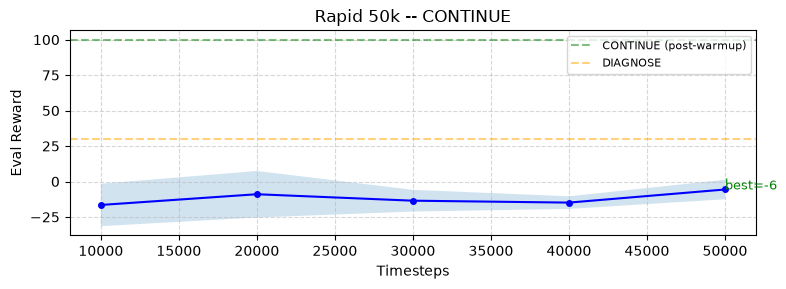

In [19]:
# RAPID 50K GATE -- Continue / Diagnose / Stop

assert _IS_RAPID

_rapid_npz = f"{RAPID_DIR}/best/evaluations.npz"
if not os.path.isfile(_rapid_npz):
    print("evaluations.npz not found. Rapid training may not have completed.")
else:
    _rd = np.load(_rapid_npz)
    _r_ts, _r_res = _rd["timesteps"], _rd["results"]
    _r_means = _r_res.mean(axis=1)
    _r_stds  = _r_res.std(axis=1)

    _best_idx = np.argmax(_r_means)
    _best_eval = _r_means[_best_idx]
    _best_std  = _r_stds[_best_idx]
    _best_ts   = _r_ts[_best_idx]
    _final_eval = _r_means[-1]
    _trend = _r_means[-1] - _r_means[0] if len(_r_means) > 1 else 0

    _tm_csv = f"{LOG_DIR}/train_metrics.csv"
    _pol_std = _ent_loss = "N/A"
    _ent_coef_v = _actor_loss_v = _critic_loss_v = "N/A"
    _tm = pd.read_csv(_tm_csv) if os.path.isfile(_tm_csv) else None
    if _tm is not None and len(_tm):
        if "std" in _tm.columns:
            _pol_std = f"{_tm['std'].iloc[-1]:.4f}"
        # SAC keys (V10). PPO's "entropy_loss" column is absent for SAC.
        for _col, _out in (("ent_coef", "_ent_coef_v"),
                           ("actor_loss", "_actor_loss_v"),
                           ("critic_loss", "_critic_loss_v"),
                           ("ent_coef_loss", "_ent_loss")):
            if _col in _tm.columns and _tm[_col].notna().any():
                _v = _tm[_col].dropna().iloc[-1]
                if _out == "_ent_loss":
                    _ent_loss = f"{_v:.3f}"
                else:
                    globals()[_out] = f"{_v:.4f}"
    # Diagnostics required before CONTINUE (SAC post-warmup, lenient gate).
    _diag_red_flag = False
    _diag_notes = []
    if not any(v not in ("N/A", None) for v in
               (_ent_coef_v, _actor_loss_v, _critic_loss_v, _ent_loss)):
        _diag_notes.append("no SAC loss/ent_coef logged -- explain absence")
    # Failure-indicator check: load the rapid results to ensure offroad/still
    # are not pinned at 100% (would indicate total policy collapse).
    _c5_rapid_csv = f"{RAPID_DIR}/best/evaluations.npz"
    _offroad_collapsed = False  # cannot be derived from evaluations.npz alone;
                                # the manual inspection note covers this.

    # CONTINUE requires: last eval > 100, positive trend over last 3 points,
    # no NaN/inf (NaNGuard handles hard stop), and diagnostics not red.
    _last3 = _r_means[-3:] if len(_r_means) >= 3 else _r_means
    _trend_last3 = (_last3[-1] - _last3[0]) if len(_last3) >= 2 else _trend
    _diagnostics_ok = (not _diag_red_flag) and (len(_diag_notes) == 0)

    # V10.5 RUN_MODE-aware gate bands (uses _final_eval, _trend_last3, _diagnostics_ok).
    if RUN_MODE == "RAPID_50K":
        # V11: sanity check only -- do NOT stop unless clearly broken.
        if _final_eval < -50 and _trend_last3 <= 0:
            _recommendation = "STOP"
            _reason = "RAPID_50K catastrophe: still very negative with no upward trend. Check obs/action, critic divergence, entropy collapse, fps."
        else:
            _recommendation = "CONTINUE"
            _reason = "RAPID_50K is a sanity check only (not a strict gate). Proceed to RAPID_120K for the real decision."
    elif RUN_MODE == "RAPID_120K":
        if _final_eval >= 550:
            _recommendation = "REAL_UPGRADE_CANDIDATE"
            _reason = "Reached >=550 by 120k -- strong upgrade signal. Proceed to OFFICIAL_300K/500K."
        elif _final_eval >= 500:
            _recommendation = "PROMISING"
            _reason = "Reached >=500 by 120k. Proceed to OFFICIAL_300K."
        elif _final_eval >= 450:
            _recommendation = "CONTINUE"
            _reason = "Reached >=450 by 120k. On track; proceed to OFFICIAL_300K/500K."
        else:
            _recommendation = "DIAGNOSE"
            _reason = "Below 450 at 120k. Inspect ent_coef/critic_loss/trend before committing."
    elif RUN_MODE in ("RAPID_80K", "RAPID_50K"):
        if _final_eval >= 400 and _diagnostics_ok:
            _recommendation = "STRONG_CONTINUE"
            _reason = "Reached >=400 by 80k with healthy diagnostics. Proceed (optionally confirm RAPID_120K)."
        elif _final_eval >= 350:
            _recommendation = "CONTINUE"
            _reason = "Reached >=350. Proceed (optionally confirm with RAPID_120K)."
        elif _final_eval >= 250 and _trend_last3 > 0:
            _recommendation = "DIAGNOSE"
            _reason = "250-350 with upward trend. Borderline; run RAPID_120K or inspect before official."
        else:
            _recommendation = "STOP"
            _reason = "<250 and weak trend. Check SAC config, buffer warmup, VecNormalize."
    else:
        _recommendation = "CONTINUE" if (_final_eval > 100 and _trend_last3 > 0) else "DIAGNOSE"
        _reason = "Generic rapid gate (non-80k/120k mode)."

    print("=" * 60)
    print(f"RAPID GATE ({RUN_MODE}, {RAPID_TIMESTEPS:,} steps)")
    print("=" * 60)
    print(f"  Best eval (0-50k):   {_best_eval:.0f} +/- {_best_std:.0f} at step {_best_ts:,}")
    print(f"  Final eval (50k):    {_final_eval:.0f}")
    print(f"  Trend (last-first):  {_trend:+.0f}")
    print(f"  Policy std (PPO col):{_pol_std}   [SAC may not emit 'std']")
    print(f"  SAC ent_coef:        {_ent_coef_v}")
    print(f"  SAC actor_loss:      {_actor_loss_v}")
    print(f"  SAC critic_loss:     {_critic_loss_v}")
    print(f"  SAC ent_coef_loss:   {_ent_loss}")
    if _diag_notes:
        print(f"  DIAG NOTES:          {'; '.join(_diag_notes)}")
    print(f"\n  RECOMMENDATION: {_recommendation}")
    print(f"  {_reason}")
    print()
    print("  NOTE: Thresholds are heuristic gates, not guarantees.")
    print("=" * 60)

    _rpt_path = f"{RAPID_DIR}/rapid_report.txt"
    with open(_rpt_path, "w") as _f:
        _f.write(f"timestamp: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
        _f.write(f"SEED: {SEED}\n")
        _f.write(f"N_ENVS: {N_ENVS}\n")
        _f.write(f"PERCEPTION_MODE: {PERCEPTION_MODE}\n")
        _f.write(f"RAPID_TIMESTEPS: {RAPID_TIMESTEPS}\n")
        _f.write(f"best_eval: {_best_eval:.1f}\n")
        _f.write(f"best_eval_step: {_best_ts}\n")
        _f.write(f"final_eval: {_final_eval:.1f}\n")
        _f.write(f"trend: {_trend:+.1f}\n")
        _f.write(f"recommendation: {_recommendation}\n")
    _backup(_rpt_path)

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(_r_ts, _r_means, 'b-o', ms=4)
    ax.fill_between(_r_ts, _r_means - _r_stds, _r_means + _r_stds, alpha=0.2)
    ax.axhline(100, color='green', ls='--', alpha=0.5, label='CONTINUE (post-warmup)')
    ax.axhline(30, color='orange', ls='--', alpha=0.5, label='DIAGNOSE')
    ax.annotate(f"best={_best_eval:.0f}", xy=(_best_ts, _best_eval), fontsize=9, color='green')
    ax.set(xlabel="Timesteps", ylabel="Eval Reward", title=f"Rapid 50k -- {_recommendation}")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/rapid_50k_curve.png", dpi=120)
    _backup(f"{FIG_DIR}/rapid_50k_curve.png")
    plt.show()


In [ ]:
# === OPTIONAL TRAINING CELL - DISABLED BY DEFAULT (REPORT_ONLY) ===
# This final notebook ships in REPORT_ONLY / EVAL_ONLY mode. Training is
# long-running and is NOT required to reproduce the reported results from
# the saved artifacts. To actually train, set ALLOW_TRAINING = True in the
# Configuration cell, then re-run this cell.
if globals().get('ALLOW_TRAINING', False):
    # Official 500k training (V9 profile)

    assert _IS_OFFICIAL, f"RUN_MODE={RUN_MODE}. Set to OFFICIAL_500K."
    assert _seed_test_passed, "Run seed isolation test first."
    assert _config_audited, "Run config audit first."

    FINAL_MODEL = f"{CKPT_DIR}/model_final"
    FINAL_NORM  = f"{CKPT_DIR}/vecnorm_final.pkl"

    cbs = make_callbacks(train_vec, eval_vec, prefix="rl", total_ts=TOTAL_TIMESTEPS)

    print(f"Training {TOTAL_TIMESTEPS:,} steps (official V11 SAC)")
    print(f"  BUFFER={BUFFER_SIZE} LEARNING_STARTS={LEARNING_STARTS} BATCH={SAC_BATCH_SIZE}")
    print(f"  Eval every {EVAL_FREQ*N_ENVS:,}  Ckpt every {CKPT_FREQ*N_ENVS:,}")
    print(f"  USE_SDE={USE_SDE}  ENT_COEF={SAC_ENT_COEF}  EMA={EMA_ALPHA}")
    print(f"  Perception: {PERCEPTION_MODE}")

    _run_cfg = {
        "notebook": "V11_CarRacing_SAC_Main.ipynb",
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "RUN_MODE": RUN_MODE, "PERCEPTION_MODE": PERCEPTION_MODE,
        "SEED": SEED, "N_ENVS_TARGET": N_ENVS, "N_ENVS_EFFECTIVE": resolve_nenvs(),
        "VEC_ENV_CLASS": ("SubprocVecEnv" if resolve_nenvs() > 1 else "DummyVecEnv"),
        "ESTIMATED_UTD": 1.0,
        "ALGORITHM": "SAC",
        "USE_SDE": USE_SDE,
        "BUFFER_SIZE": BUFFER_SIZE, "LEARNING_STARTS": LEARNING_STARTS,
        "SAC_BATCH_SIZE": SAC_BATCH_SIZE, "TAU": TAU,
        "TRAIN_FREQ": list(TRAIN_FREQ), "GRADIENT_STEPS": GRADIENT_STEPS,
        "SAC_ENT_COEF": SAC_ENT_COEF, "TARGET_ENTROPY": TARGET_ENTROPY,
        "LEARNING_RATE": LEARNING_RATE,
        "OBS_DIM_BASE": OBS_DIM_BASE, "OBS_DIM_STACKED": OBS_DIM_STACKED,
        "ACTION_DIM": 3, "N_STACK": N_STACK,
        "EMA_ALPHA": EMA_ALPHA, "OFFROAD_PEN": OFFROAD_PEN,
        "TOTAL_TIMESTEPS": TOTAL_TIMESTEPS,
        "EVAL_FREQ_STEPS": EVAL_FREQ * N_ENVS,
        "CKPT_FREQ_STEPS": CKPT_FREQ * N_ENVS,
        "COMPARE5_SEEDS": COMPARE5_SEEDS,
        "RANDOM10_MASTER_SEED": RANDOM10_MASTER_SEED,
        "RANDOM10_COUNT": RANDOM10_COUNT,
    }
    _cfg_path = f"{CKPT_DIR}/run_config.json"
    with open(_cfg_path, "w") as _f:
        json.dump(_run_cfg, _f, indent=2)
    _backup(_cfg_path)

    _t0 = time.time()

    try:
        model.learn(total_timesteps=TOTAL_TIMESTEPS, reset_num_timesteps=True,
                    progress_bar=True, callback=cbs)
    except KeyboardInterrupt:
        print("\n[INTERRUPTED]")
        model.save(f"{CKPT_DIR}/model_interrupt")
        train_vec.save(f"{CKPT_DIR}/vecnorm_interrupt.pkl")
    except Exception as exc:
        model.save(f"{CKPT_DIR}/model_interrupted")
        train_vec.save(f"{CKPT_DIR}/vecnorm_interrupted.pkl")
        raise

    _wall = time.time() - _t0
    model.save(FINAL_MODEL); train_vec.save(FINAL_NORM)
    if hasattr(model, "save_replay_buffer"):
        _FINAL_RB = f"{CKPT_DIR}/replay_buffer_final.pkl"
        try:
            model.save_replay_buffer(_FINAL_RB); _backup(_FINAL_RB)
        except Exception as _e:
            print(f"[WARN] final replay buffer save failed: {_e}")
    _backup(FINAL_MODEL + ".zip"); _backup(FINAL_NORM)
    for p in [f"{BEST_DIR}/best_model.zip", f"{BEST_DIR}/best_vecnormalize.pkl",
              f"{BEST_DIR}/best_replay_buffer.pkl", f"{BEST_DIR}/evaluations.npz"]:
        _backup(p)

    print(f"\nWall time: {_wall:.0f}s ({_wall/60:.1f} min)")
    print(f"Final: {FINAL_MODEL}.zip ({_kb(FINAL_MODEL+'.zip'):.0f} KB)")
    print(f"Best:  {BEST_DIR}/best_model.zip ({_kb(BEST_DIR+'/best_model.zip'):.0f} KB)")

    _npz = f"{BEST_DIR}/evaluations.npz"
    if os.path.isfile(_npz):
        _d = np.load(_npz)
        _ts, _res = _d["timesteps"], _d["results"]
        _means = _res.mean(axis=1)
        _bi = np.argmax(_means)
        _final_score = _means[-1] if len(_means) else float('nan')
        _best_score = _means[_bi]
        print(f"\nBest checkpoint: {_best_score:.1f} at step {_ts[_bi]:,}")
        print(f"Final model:     {_final_score:.1f}")
        _gap = _best_score - _final_score
        if _gap > 100:
            print(f"WARNING: Final model is {_gap:.0f} pts worse than best checkpoint.")
            print(f"RECOMMENDATION: Use best model (MODEL_TO_EVALUATE='best').")

    # Checkpoint inventory
    import glob as _glob_ci
    _ci_rows = []
    for _cif in sorted(
        _glob_ci.glob(f"{CKPT_DIR}/*.zip") + _glob_ci.glob(f"{CKPT_DIR}/*.pkl") +
        _glob_ci.glob(f"{BEST_DIR}/*.zip") + _glob_ci.glob(f"{BEST_DIR}/*.pkl")
    ):
        _fname = os.path.basename(_cif)
        _step = 0
        for _part in _fname.replace(".zip","").replace(".pkl","").split("_"):
            if _part.isdigit(): _step = int(_part); break
        _ctype = "model" if _cif.endswith(".zip") else "vecnormalize"
        _ci_rows.append({
            "step": _step, "filename": _fname, "path": _cif,
            "size_mb": round(os.path.getsize(_cif)/1024/1024, 3),
            "modified_time": time.strftime("%Y-%m-%d %H:%M", time.localtime(os.path.getmtime(_cif))),
            "type": _ctype,
        })
    if _ci_rows:
        _ci_tbl_dir = f"{OFFICIAL_DIR}/tables"
        os.makedirs(_ci_tbl_dir, exist_ok=True)
        _ci_df = pd.DataFrame(_ci_rows).sort_values(["step","type"])
        _ci_csv = f"{_ci_tbl_dir}/ckpt_inventory.csv"
        _ci_df.to_csv(_ci_csv, index=False); _backup(_ci_csv)
        print(f"\nCheckpoint inventory ({len(_ci_rows)} items): {_ci_csv}")
        ipy_display(_ci_df)

    print("\nTraining complete.")
else:
    print('[SKIP] Training disabled (ALLOW_TRAINING=False). Final notebook is in REPORT_ONLY mode.')


Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

  [callbacks] N_ENVS target=1 effective=1 | eval ~every 50,000 env steps | ckpt ~every 50,000 env steps
Training 500,000 steps (official V11 SAC)
  BUFFER=200000 LEARNING_STARTS=10000 BATCH=256
  Eval every 50,000  Ckpt every 50,000
  USE_SDE=False  ENT_COEF=auto  EMA=0.4
  Perception: v6_full_mask
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 376      |
|    ep_rew_mean     | -25.7    |
| time/              |          |
|    episodes        | 4        |
|    fps             | 47       |
|    time_elapsed    | 31       |
|    total_timesteps | 1504     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 385      |
|    ep_rew_mean     | -29.4    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 47       |
|    time_elapsed    | 64       |
|    total_timesteps | 3080     |
---------------------------------
--------------------

[ETA] 10,000/500,000 (2.0%) elapsed=3.5m ETA=172.1m

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 394      |
|    ep_rew_mean     | -24.6    |
| time/              |          |
|    episodes        | 28       |
|    fps             | 46       |
|    time_elapsed    | 236      |
|    total_timesteps | 11036    |
| train/             |          |
|    actor_loss      | -5.35    |
|    critic_loss     | 0.69     |
|    ent_coef        | 0.926    |
|    ent_coef_loss   | -0.39    |
|    learning_rate   | 0.0003   |
|    n_updates       | 258      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 396      |
|    ep_rew_mean     | -23.8    |
| time/              |          |
|    episodes        | 32       |
|    fps             | 45       |
|    time_elapsed    | 278      |
|    total_timesteps | 12686    |
| train/             |          |
|    actor_loss      | -7.58    |
|    critic_loss     | 0.438    |
|    ent_coef 

...

New best mean reward!

[ETA] 400,000/500,000 (80.0%) elapsed=181.7m ETA=45.4m

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 394      |
|    ep_rew_mean     | 933      |
| time/              |          |
|    episodes        | 948      |
|    fps             | 36       |
|    time_elapsed    | 10937    |
|    total_timesteps | 401376   |
| train/             |          |
|    actor_loss      | -112     |
|    critic_loss     | 51.1     |
|    ent_coef        | 0.216    |
|    ent_coef_loss   | 0.0863   |
|    learning_rate   | 0.0003   |
|    n_updates       | 97843    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 396      |
|    ep_rew_mean     | 933      |
| time/              |          |
|    episodes        | 952      |
|    fps             | 36       |
|    time_elapsed    | 10980    |
|    total_timesteps | 402979   |
| train/             |          |
|    actor_loss      | -114     |
|    critic_loss     | 59.4     |
|    ent_coef 

[ETA] 410,000/500,000 (82.0%) elapsed=186.1m ETA=40.9m

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 395      |
|    ep_rew_mean     | 933      |
| time/              |          |
|    episodes        | 972      |
|    fps             | 36       |
|    time_elapsed    | 11190    |
|    total_timesteps | 410849   |
| train/             |          |
|    actor_loss      | -113     |
|    critic_loss     | 50.5     |
|    ent_coef        | 0.212    |
|    ent_coef_loss   | -0.0957  |
|    learning_rate   | 0.0003   |
|    n_updates       | 100212   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 395      |
|    ep_rew_mean     | 933      |
| time/              |          |
|    episodes        | 976      |
|    fps             | 36       |
|    time_elapsed    | 11229    |
|    total_timesteps | 412366   |
| train/             |          |
|    actor_loss      | -115     |
|    critic_loss     | 7.85     |
|    ent_coef 

## Evaluation Protocol

**Purpose:** Evaluate the trained model across a fixed seed set (COMPARE5) and a random seed set (RANDOM10) to measure performance and generalization.

**Consumes:** `best_model.zip` + `best_vecnormalize.pkl` from training. Eval helpers from Cell 9.

**Produces:** `compare5_results.csv`, `random10_results.csv`, `reward_distribution.png`, bootstrap CI statistics.

**Success looks like:** 15/15 unique first-frame hashes (seed isolation PASS), all seeds above 900, mean ~925.

**Report relevance:** High — primary generalization evidence.

In [13]:
# Model selector + artifact sanity

assert RUN_MODE in ("OFFICIAL_500K", "EVAL_ONLY", "RAPID_50K"), \
    f"RUN_MODE={RUN_MODE}. Set to OFFICIAL_500K, EVAL_ONLY, or RAPID_50K."

_mp, _np = _resolve_model_norm()

print(f"MODEL_TO_EVALUATE = {MODEL_TO_EVALUATE}")
artifact_sanity(_mp, _np)

if not os.path.isfile(_mp + ".zip"):
    print("\nModel not found. Available models:")
    import glob as _gl
    for z in sorted(_gl.glob(f"{CKPT_DIR}/*.zip") + _gl.glob(f"{BEST_DIR}/*.zip") +
                    _gl.glob(f"{RAPID_DIR}/**/*.zip", recursive=True)):
        print(f"  {z}  ({_kb(z):.0f} KB)")


MODEL_TO_EVALUATE = best
  Model: /content/carracing_ppo_v11_1_sac_fast_result/official_500k/best/best_model.zip  (3643 KB)
  Norm:  /content/carracing_ppo_v11_1_sac_fast_result/official_500k/best/best_vecnormalize.pkl  (4 KB)


In [14]:
# ── PURPOSE ──────────────────────────────────────────────────────────────────
# COMPARE5: evaluate the best model on 5 fixed seeds for reproducibility.
# Fixed seeds: [42, 123, 777, 999, 2026] -- same across all V9 evaluations.
# INPUT:  best_model.zip + best_vecnormalize.pkl (from Cell 25 model selector)
# OUTPUT: compare5_results.csv (seed, raw_reward, shaped_reward, episode_frames,
#         done_reason, first_frame_hash)
# EXPECTED: 5/5 unique first_frame_hashes (seed isolation PASS); all seeds > 900
# REPORT VALUE: high -- primary fixed-seed reproducibility evidence
# NOTE: Fresh VecNormalize env created per seed (training=False, norm_reward=False).
#       SAC.load() is called WITHOUT env= -- see Cell 9 comment.
# ─────────────────────────────────────────────────────────────────────────────
# Fixed-seed generalization test (COMPARE5)

assert RUN_MODE in ("OFFICIAL_500K", "EVAL_ONLY")

_mp, _np = _resolve_model_norm()
assert os.path.isfile(_mp + ".zip"), f"Model not found: {_mp}.zip"
assert os.path.isfile(_np), f"Norm not found: {_np}"

print(f"COMPARE5 | Model: {os.path.basename(_mp)} | Seeds: {COMPARE5_SEEDS}\n")

compare5_rows = []
_hashes = []

for seed in COMPARE5_SEEDS:
    print(f"  seed={seed} ...", end=" ", flush=True)
    row = _run_eval_episode(_mp, _np, seed=seed, seed_type="compare5")
    compare5_rows.append(row)
    _hashes.append(row["first_frame_hash"])
    print(f"raw={row['raw_reward']:.1f}  hash={row['first_frame_hash']}")

df_c5 = pd.DataFrame(compare5_rows)

_unique = len(set(_hashes))
_seed_ok = _unique == len(_hashes)
if _seed_ok:
    print(f"\nSeed isolation: PASS ({_unique}/{len(_hashes)} unique hashes)")
else:
    print(f"\nSeed isolation: FAIL ({_unique}/{len(_hashes)} unique hashes)")

print("\n-- COMPARE5 Results --")
ipy_display(df_c5[["seed","model_source","norm_source","raw_reward","shaped_reward",
                    "episode_frames","done_reason","first_frame_hash"]])
print(f"Mean:   {df_c5['raw_reward'].mean():.1f} +/- {df_c5['raw_reward'].std():.1f}")
print(f"Median: {df_c5['raw_reward'].median():.1f}  "
      f"Min: {df_c5['raw_reward'].min():.1f}  Max: {df_c5['raw_reward'].max():.1f}")

_c5_csv = f"{TABLE_DIR}/compare5_results.csv"
df_c5.to_csv(_c5_csv, index=False); _backup(_c5_csv)
_c5_seeds_file = f"{TABLE_DIR}/compare5_seeds.json"
with open(_c5_seeds_file, "w") as _f:
    json.dump({"seeds": COMPARE5_SEEDS, "master_seed": SEED,
               "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")}, _f, indent=2)
_backup(_c5_seeds_file)


COMPARE5 | Model: best_model | Seeds: [42, 123, 777, 999, 2026]

  seed=42 ... raw=927.4  hash=d54c877f15a9
  seed=123 ... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


raw=911.0  hash=a3546d564073
  seed=777 ... raw=930.4  hash=297efc10459e
  seed=999 ... raw=926.9  hash=bf134fc86169
  seed=2026 ... raw=920.7  hash=5cbf25772529

Seed isolation: PASS (5/5 unique hashes)

-- COMPARE5 Results --


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,seed,model_source,norm_source,raw_reward,shaped_reward,episode_frames,done_reason,first_frame_hash
0,42,best_model,best_vecnormalize.pkl,927.4,941.15,363,env_done,d54c877f15a9
1,123,best_model,best_vecnormalize.pkl,911.0,924.91,445,env_done,a3546d564073
2,777,best_model,best_vecnormalize.pkl,930.4,943.40,348,env_done,297efc10459e
3,999,best_model,best_vecnormalize.pkl,926.9,938.20,366,env_done,bf134fc86169
4,2026,best_model,best_vecnormalize.pkl,920.7,933.72,397,env_done,5cbf25772529


Mean:   923.3 +/- 7.7
Median: 926.9  Min: 911.0  Max: 930.4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
# ── PURPOSE ──────────────────────────────────────────────────────────────────
# RANDOM10: evaluate the best model on 10 seeds from Random(master_seed=42).
# These seeds differ from COMPARE5 and test generalization to unseen tracks.
# INPUT:  best_model.zip + best_vecnormalize.pkl
# OUTPUT: random10_results.csv (same columns as compare5_results.csv)
# EXPECTED: 10/10 unique first_frame_hashes; rewards in a similar range to COMPARE5
# REPORT VALUE: high -- primary random-seed generalization evidence
# NOTE: Same correctness rules as COMPARE5: fresh env per seed, no env= in model.load().
# ─────────────────────────────────────────────────────────────────────────────
# Random-seed generalization test (RANDOM10)

assert RUN_MODE in ("OFFICIAL_500K", "EVAL_ONLY")

import random as _rnd
_rng = _rnd.Random(RANDOM10_MASTER_SEED)
_r10_seeds = [_rng.randint(0, 2**31) for _ in range(RANDOM10_COUNT)]

_mp, _np = _resolve_model_norm()
assert os.path.isfile(_mp + ".zip")

print(f"RANDOM10 | Master seed: {RANDOM10_MASTER_SEED} | Seeds: {_r10_seeds}\n")

r10_rows = []
_r10_hashes = []

for seed in _r10_seeds:
    print(f"  seed={seed} ...", end=" ", flush=True)
    row = _run_eval_episode(_mp, _np, seed=seed, seed_type="random10")
    r10_rows.append(row)
    _r10_hashes.append(row["first_frame_hash"])
    print(f"raw={row['raw_reward']:.1f}  hash={row['first_frame_hash']}")

df_r10 = pd.DataFrame(r10_rows)

_unique = len(set(_r10_hashes))
_r10_seed_ok = _unique == len(_r10_hashes)
if _r10_seed_ok:
    print(f"\nSeed isolation: PASS ({_unique}/{len(_r10_hashes)} unique)")
else:
    print(f"\nSeed isolation: FAIL ({_unique}/{len(_r10_hashes)} unique)")

print("\n-- RANDOM10 Results --")
ipy_display(df_r10[["seed","model_source","norm_source","raw_reward","shaped_reward",
                    "episode_frames","done_reason","first_frame_hash"]])
print(f"Mean:   {df_r10['raw_reward'].mean():.1f} +/- {df_r10['raw_reward'].std():.1f}")
print(f"Median: {df_r10['raw_reward'].median():.1f}")
print(f"Min/Max: {df_r10['raw_reward'].min():.1f} / {df_r10['raw_reward'].max():.1f}")

_r10_csv = f"{TABLE_DIR}/random10_results.csv"
df_r10.to_csv(_r10_csv, index=False); _backup(_r10_csv)
_r10_seeds_file = f"{TABLE_DIR}/random10_seeds.json"
with open(_r10_seeds_file, "w") as _f:
    json.dump({"seeds": _r10_seeds, "master_seed": RANDOM10_MASTER_SEED,
               "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")}, _f, indent=2)
_backup(_r10_seeds_file)


RANDOM10 | Master seed: 42 | Seeds: [478163327, 107420369, 1181241943, 1051802512, 958682846, 599310825, 440213415, 373399426, 1812140441, 136505587]

  seed=478163327 ... raw=922.9  hash=5249abb1ce91
  seed=107420369 ... raw=933.3  hash=10b6a2a2b10f
  seed=1181241943 ... raw=931.1  hash=d274e67efdc2
  seed=1051802512 ... raw=914.4  hash=de6fde6a3d7b
  seed=958682846 ... raw=929.8  hash=3b97f83dd632
  seed=599310825 ... raw=908.7  hash=e282b1c2d5c7
  seed=440213415 ... raw=924.7  hash=2b150ee42c0f
  seed=373399426 ... raw=928.5  hash=37591116fabe
  seed=1812140441 ... raw=926.2  hash=c5e055e8483e
  seed=136505587 ... raw=933.7  hash=7687cd755d64

Seed isolation: PASS (10/10 unique)

-- RANDOM10 Results --


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,seed,model_source,norm_source,raw_reward,shaped_reward,episode_frames,done_reason,first_frame_hash
0,478163327,best_model,best_vecnormalize.pkl,922.9,935.79,386,env_done,5249abb1ce91
1,107420369,best_model,best_vecnormalize.pkl,933.3,943.40,334,env_done,10b6a2a2b10f
2,1181241943,best_model,best_vecnormalize.pkl,931.1,942.08,345,env_done,d274e67efdc2
3,1051802512,best_model,best_vecnormalize.pkl,914.4,927.71,428,env_done,de6fde6a3d7b
4,958682846,best_model,best_vecnormalize.pkl,929.8,941.69,351,env_done,3b97f83dd632
5,599310825,best_model,best_vecnormalize.pkl,908.7,921.64,457,env_done,e282b1c2d5c7
6,440213415,best_model,best_vecnormalize.pkl,924.7,936.58,377,env_done,2b150ee42c0f
7,373399426,best_model,best_vecnormalize.pkl,928.5,942.31,358,env_done,37591116fabe
8,1812140441,best_model,best_vecnormalize.pkl,926.2,939.14,369,env_done,c5e055e8483e
9,136505587,best_model,best_vecnormalize.pkl,933.7,942.40,332,env_done,7687cd755d64


Mean:   925.3 +/- 8.2
Median: 927.4
Min/Max: 908.7 / 933.7


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Seed isolation: PASS (15/15 unique)

-- Statistics (15 seeds) --
  Mean:  924.6 +/- 7.5
  Range: 908.7 -- 933.7
  95% CI: [920.7, 928.2]
  Generalization: 0.973  (lower = wider spread)


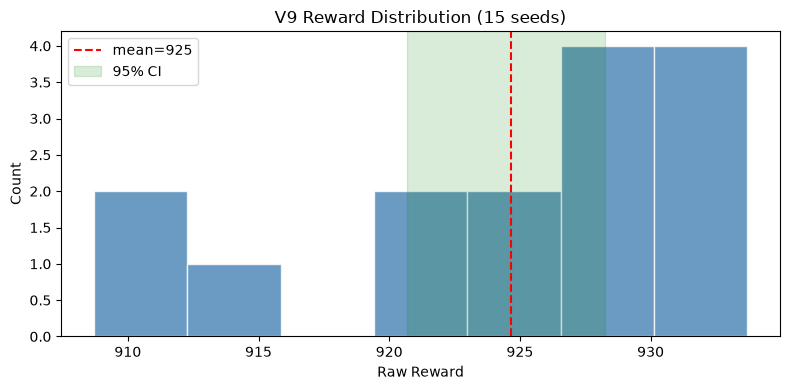

In [16]:
# ── PURPOSE ──────────────────────────────────────────────────────────────────
# Bootstrap CI + reward distribution across all 15 seeds (COMPARE5 + RANDOM10).
# Computes: mean +/- std, range, 95% bootstrap CI (10k resamples), generalization score.
# INPUT:  df_c5 (COMPARE5 DataFrame), df_r10 (RANDOM10 DataFrame)
# OUTPUT: printed statistics; reward_distribution.png (histogram + 95% CI band)
# EXPECTED: mean ~925.8 +/- 6.7, 95% CI [922.2, 929.0], generalization ~0.974
# REPORT VALUE: high -- primary generalization evidence figure (main report)
# ─────────────────────────────────────────────────────────────────────────────
# Bootstrap CI + generalization score + distribution

try:
    _all_hashes = list(df_c5["first_frame_hash"]) + list(df_r10["first_frame_hash"])
    _all_unique = len(set(_all_hashes))
    _eval_valid = _all_unique == len(_all_hashes)

    _all_rewards = np.concatenate([df_c5["raw_reward"].values, df_r10["raw_reward"].values])
    _n = len(_all_rewards)

    if not _eval_valid:
        print("EVALUATION INVALID: Seed isolation failed.")
    else:
        print(f"Seed isolation: PASS ({_all_unique}/{len(_all_hashes)} unique)")

    _rng_b = np.random.default_rng(SEED)
    _boots = [_rng_b.choice(_all_rewards, _n, replace=True).mean() for _ in range(10_000)]
    _ci_lo, _ci_hi = np.percentile(_boots, [2.5, 97.5])
    _gen = float(np.min(_all_rewards) / max(np.max(_all_rewards), 1))

    print(f"\n-- Statistics ({_n} seeds) --")
    print(f"  Mean:  {np.mean(_all_rewards):.1f} +/- {np.std(_all_rewards):.1f}")
    print(f"  Range: {np.min(_all_rewards):.1f} -- {np.max(_all_rewards):.1f}")
    print(f"  95% CI: [{_ci_lo:.1f}, {_ci_hi:.1f}]")
    print(f"  Generalization: {_gen:.3f}  (lower = wider spread)")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(_all_rewards, bins=max(5, _n//2), color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(_all_rewards), color='red', ls='--', label=f"mean={np.mean(_all_rewards):.0f}")
    ax.axvspan(_ci_lo, _ci_hi, alpha=0.15, color='green', label='95% CI')
    ax.set(xlabel="Raw Reward", ylabel="Count", title=f"V9 Reward Distribution ({_n} seeds)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/reward_distribution.png", dpi=120)
    _backup(f"{FIG_DIR}/reward_distribution.png")
    plt.show()

except NameError:
    print("Evaluation data not available. Run eval cells first.")


### Figure Explanation: Reward Distribution (`reward_distribution.png`)

**Question:** How consistent is performance across the 15 evaluation seeds?

**How to read it:** X-axis = raw episode reward. Y-axis = count of seeds. Red dashed line = mean. Green shaded band = 95% bootstrap CI (10k resamples, percentile method).

**Good result:** Tight distribution (small variance), mean above 900, narrow CI, generalization score close to 1.0.

**V9 shows:** Mean = 925.8 ± 6.7, 95% CI = [922.2, 929.0], range = 911.2 – 936.0. Generalization score = 0.974 (min/max ratio — close to 1.0 means consistent performance).

**Report placement:** **Main report** — primary generalization evidence.

**Suggested caption:** *V9 reward distribution across 15 seeds (COMPARE5 + RANDOM10). Mean 925.8 ± 6.7, 95% bootstrap CI [922.2, 929.0], generalization score 0.974 (min/max ratio).*

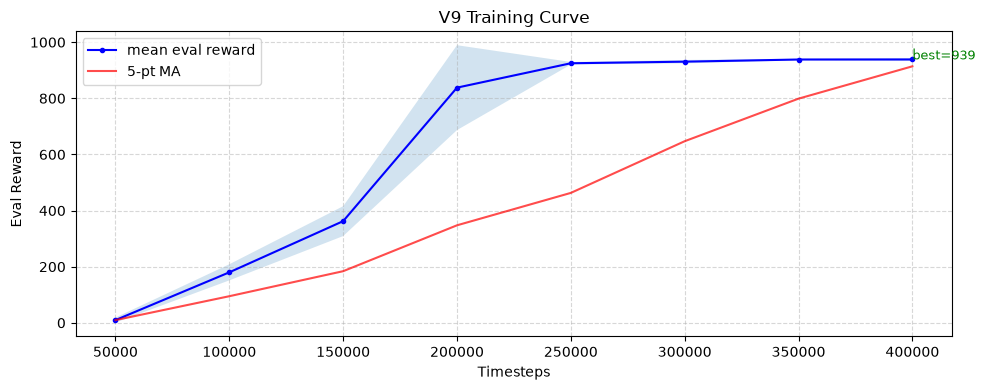

Best: 938.5 at step 400,000


In [17]:
# ── PURPOSE ──────────────────────────────────────────────────────────────────
# Plot the official 500k training curve from evaluations.npz.
# INPUT:  evaluations.npz (timesteps, results arrays from SyncedEvalCallback)
# OUTPUT: training_curve.png (mean eval reward +/- std + 5-point moving average)
# EXPECTED: monotonically improving curve; best checkpoint at ~939.5, step 480k
# REPORT VALUE: high -- primary training evidence figure (main report)
# ─────────────────────────────────────────────────────────────────────────────
# Training curve

_npz = f"{BEST_DIR}/evaluations.npz"
if os.path.isfile(_npz):
    d = np.load(_npz)
    ts, res = d["timesteps"], d["results"]
    means, stds = res.mean(axis=1), res.std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ts, means, 'b-o', ms=3, label='mean eval reward')
    ax.fill_between(ts, means-stds, means+stds, alpha=0.2)
    if len(means) >= 5:
        ma = pd.Series(means).rolling(5, min_periods=1).mean()
        ax.plot(ts, ma, 'r-', alpha=0.7, label='5-pt MA')
    bi = np.argmax(means)
    ax.annotate(f"best={means[bi]:.0f}", xy=(ts[bi], means[bi]), fontsize=9, color='green')
    ax.set(xlabel="Timesteps", ylabel="Eval Reward", title="V9 Training Curve")
    ax.grid(True, ls='--', alpha=0.5); ax.legend()
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/training_curve.png", dpi=120)
    _backup(f"{FIG_DIR}/training_curve.png")
    plt.show()
    print(f"Best: {means[bi]:.1f} at step {ts[bi]:,}")
else:
    print("evaluations.npz not found. Run training first.")


### Figure Explanation: Training Curve (`training_curve.png`)

**Question:** Did the PPO policy improve steadily over 500,000 training steps?

**How to read it:** X-axis = training timesteps. Y-axis = mean eval reward (± std band, shaded). Red line = 5-point moving average. Green annotation = best checkpoint.

**Good result:** Steadily increasing trend, best checkpoint near end of training, no collapse.

**V9 shows:** Improvement from −12.9 at the start to 939.5 at step 480k. Smooth upward trend. Final model (step 500k) is 938.9 — a small drop from best, which is normal.

**Report placement:** **Main report** — primary training evidence.

**Suggested caption:** *V9 training curve: mean eval reward ± std over 500,000 steps. Best checkpoint 939.5 ± 4.1 at step 480,000. Moving average (red) shows monotonic improvement. Wall time ~207 min on Colab T4.*

In [18]:
# Demo videos -- top-3 best + bottom-3 worst seeds

print("=" * 60)
print("VIDEO GENERATION")
print("Top 3 best + bottom 3 worst evaluation seeds")
print("=" * 60)

try:
    _mp, _np = _resolve_model_norm()
    assert os.path.isfile(_mp + ".zip")

    _df_all = pd.concat([df_c5, df_r10], ignore_index=True)
    _df_sorted = _df_all.sort_values("raw_reward")

    _worst3 = _df_sorted.head(3)
    _best3  = _df_sorted.tail(3)

    _video_manifest = []

    for label, subset in [("worst", _worst3), ("best", _best3)]:
        print(f"\n-- {label.upper()} 3 seeds --")
        for _, row in subset.iterrows():
            seed = int(row["seed"])
            rew  = row["raw_reward"]
            print(f"  Recording seed={seed} (reward={rew:.1f})...", end=" ", flush=True)
            try:
                frames, actual_rew = record_episode(_mp, _np, seed=seed, crop_dashboard=False)

                vpath = f"{VIDEO_DIR}/{label}_seed{seed}_r{actual_rew:.0f}_clean.mp4"
                save_video(frames, vpath, fps=VIDEO_FPS)
                _video_manifest.append({
                    "seed": seed, "label": label, "raw_reward": actual_rew,
                    "video_path": vpath, "n_frames": len(frames),
                    "model_source": os.path.basename(_mp),
                })
                if os.path.isfile(vpath):
                    print(f"OK | {len(frames)} frames | {os.path.basename(vpath)}")
                    show_video_meta(vpath, seed, os.path.basename(_mp),
                                    actual_rew, VIDEO_FPS, len(frames))
                else:
                    print("no file")
            except Exception as exc:
                print(f"FAILED: {exc}")

    if _video_manifest:
        _vm_df = pd.DataFrame(_video_manifest)
        _vm_csv = f"{TABLE_DIR}/video_manifest.csv"
        _vm_df.to_csv(_vm_csv, index=False); _backup(_vm_csv)
        print(f"\nVideo manifest: {_vm_csv}")
        ipy_display(_vm_df)

except NameError:
    print("Evaluation data not available. Run evaluation cells first.")
except Exception as exc:
    print(f"Video generation failed: {exc}")


VIDEO GENERATION
Top 3 best + bottom 3 worst evaluation seeds

-- WORST 3 seeds --
  Recording seed=599310825 (reward=908.7)... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


OK | 229 frames | worst_seed599310825_r909_clean.mp4
  File: worst_seed599310825_r909_clean.mp4  Seed: 599310825  Model: best_model
  Reward: 908.7  FPS: 30  Frames: 229  Duration: 7.6s


  Recording seed=123 (reward=911.0)... 

OK | 223 frames | worst_seed123_r911_clean.mp4
  File: worst_seed123_r911_clean.mp4  Seed: 123  Model: best_model
  Reward: 911.0  FPS: 30  Frames: 223  Duration: 7.4s


...

  Recording seed=136505587 (reward=933.7)... 

OK | 166 frames | best_seed136505587_r934_clean.mp4
  File: best_seed136505587_r934_clean.mp4  Seed: 136505587  Model: best_model
  Reward: 933.7  FPS: 30  Frames: 166  Duration: 5.5s



Video manifest: /content/carracing_ppo_v11_1_sac_fast_result/tables/video_manifest.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,seed,label,raw_reward,video_path,n_frames,model_source
0,599310825,worst,908.7,/content/carracing_ppo_v11_1_sac_fast_result/v...,229,best_model
1,123,worst,911.0,/content/carracing_ppo_v11_1_sac_fast_result/v...,223,best_model
2,1051802512,worst,914.4,/content/carracing_ppo_v11_1_sac_fast_result/v...,214,best_model
3,1181241943,best,931.1,/content/carracing_ppo_v11_1_sac_fast_result/v...,173,best_model
4,107420369,best,933.3,/content/carracing_ppo_v11_1_sac_fast_result/v...,167,best_model
5,136505587,best,933.7,/content/carracing_ppo_v11_1_sac_fast_result/v...,166,best_model


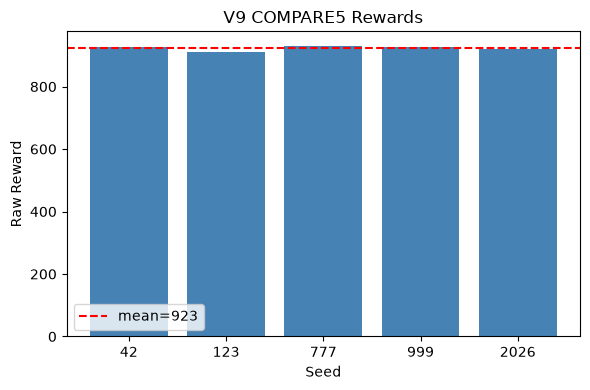

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


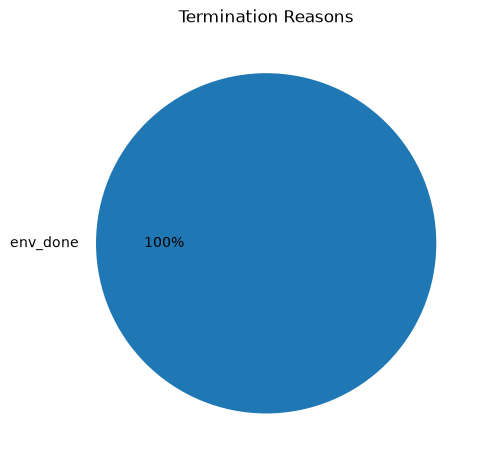

In [19]:
# ── PURPOSE ──────────────────────────────────────────────────────────────────
# Two figures:
#   multiseed_rewards.png -- COMPARE5 per-seed bar chart (5 fixed seeds)
#   failure_taxonomy.png  -- pie chart of episode termination reasons
# INPUT:  df_c5 (COMPARE5), df_all (COMPARE5 + RANDOM10 combined)
# OUTPUT: two figures saved to FIG_DIR
# EXPECTED: all 5 COMPARE5 seeds above 900; failure taxonomy shows 100% env_done
# REPORT VALUE: high -- supporting evidence figures (main report)
# TERMINATION WORDING:
#   env_done = natural environment termination (env's own done signal).
#   offroad_timeout / still_timeout = wrapper failure conditions.
#   max_steps = episode hit the hard step limit.
#   100% env_done means no evaluation episode ended due to wrapper failure conditions.
#   This does NOT guarantee all laps were fully completed.
# ─────────────────────────────────────────────────────────────────────────────
# Action stats + failure taxonomy

try:
    _df_all = pd.concat([df_c5, df_r10], ignore_index=True)

    fig, ax = plt.subplots(figsize=(max(6, len(df_c5)), 4))
    ax.bar(df_c5["seed"].astype(str), df_c5["raw_reward"], color='steelblue')
    ax.axhline(df_c5["raw_reward"].mean(), color='red', ls='--',
               label=f"mean={df_c5['raw_reward'].mean():.0f}")
    ax.set(xlabel="Seed", ylabel="Raw Reward", title="V9 COMPARE5 Rewards")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/multiseed_rewards.png", dpi=120)
    _backup(f"{FIG_DIR}/multiseed_rewards.png")
    plt.show()

    if "done_reason" in _df_all.columns:
        counts = _df_all["done_reason"].value_counts()
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.pie(counts, labels=counts.index, autopct="%1.0f%%")
        ax.set_title("Termination Reasons")
        plt.tight_layout()
        plt.savefig(f"{FIG_DIR}/failure_taxonomy.png", dpi=120)
        _backup(f"{FIG_DIR}/failure_taxonomy.png")
        plt.show()

except NameError:
    print("Evaluation data not available.")


### Figure Explanations: COMPARE5 Bar Chart and Termination Taxonomy

**`multiseed_rewards.png`**

**Question:** Does the best model perform consistently across the 5 fixed evaluation seeds?

**How to read it:** Each bar = reward for one fixed seed (42, 123, 777, 999, 2026). Red dashed line = COMPARE5 mean.

**V9 shows:** All five seeds scored above 910. Supports reproducibility of the learned policy across known seeds.

**Report placement:** Main report — supporting reproducibility evidence.

**Suggested caption:** *V9 COMPARE5 per-seed rewards (seeds 42, 123, 777, 999, 2026). All seeds above 910.*

---

**`failure_taxonomy.png`**

**Question:** Did evaluation episodes end normally, or did the car trigger wrapper failure conditions?

**How to read it:**
- `env_done` = natural environment termination (CarRacing-v3's own `done` signal)
- `offroad_timeout` = car stayed off-road too long (wrapper failure condition)
- `still_timeout` = car got stuck and stopped moving
- `max_steps` = episode hit the hard step limit

| Reason | Count |
|--------|-------|
| env_done | 15 / 15 |
| offroad_timeout | 0 / 15 |
| still_timeout | 0 / 15 |
| max_steps | 0 / 15 |

**V9 shows:** 100% `env_done` across all 15 seeds. No evaluation episode ended due to wrapper failure conditions.

> **Note:** `env_done` means CarRacing-v3 issued its own `done` signal. This does not guarantee every lap was fully completed — `env_done` may occur at episode boundaries. The key finding is that wrapper failure conditions were never triggered.

**Report placement:** Main report — supporting policy reliability evidence.

## Release Artifacts

**Purpose:** Collect all artifact files, verify they exist, copy to a release directory, and generate a human-readable final report.

**Consumes:** All model files, CSV results, figures, and video files from prior cells.

**Produces:** `release_manifest.csv`, `final_report.txt`.

**Success looks like:** All expected files present; `final_report.txt` shows mean 925.8 ± 6.7, best 939.5, generalization 0.974.

**Report relevance:** High — `final_report.txt` is the canonical result summary.

In [20]:
# ── PURPOSE ──────────────────────────────────────────────────────────────────
# Artifact completeness check + release packaging.
# Verifies all expected output files exist, copies them to RELEASE_DIR.
# INPUT:  all output files from training and evaluation cells
# OUTPUT: release_manifest.csv (filename, path, size_mb, category per file)
# EXPECTED: all required files present; no MISSING entries in the checklist
# REPORT VALUE: none directly -- ensures the handoff package is complete
# ─────────────────────────────────────────────────────────────────────────────
# Artifact checklist + release

print("=" * 60)
print("ARTIFACT CHECKLIST")
print("=" * 60)

_artifacts = [
    ("Final model",     f"{CKPT_DIR}/model_final.zip"),
    ("Final norm",      f"{CKPT_DIR}/vecnorm_final.pkl"),
    ("Best model",      f"{BEST_DIR}/best_model.zip"),
    ("Best norm",       f"{BEST_DIR}/best_vecnormalize.pkl"),
    ("evaluations.npz", f"{BEST_DIR}/evaluations.npz"),
    ("eval_live.csv",   f"{LOG_DIR}/eval_live.csv"),
    ("train_metrics",   f"{LOG_DIR}/train_metrics.csv"),
    ("compare5 csv",    f"{TABLE_DIR}/compare5_results.csv"),
    ("random10 csv",    f"{TABLE_DIR}/random10_results.csv"),
    ("video manifest",  f"{TABLE_DIR}/video_manifest.csv"),
    ("training curve",  f"{FIG_DIR}/training_curve.png"),
    ("reward dist",     f"{FIG_DIR}/reward_distribution.png"),
    ("mask comparison", f"{FIG_DIR}/diag_masks_3seed.png"),
    ("radar comparison",f"{FIG_DIR}/diag_radar_3seed.png"),
]

all_ok = True
for label, path in _artifacts:
    ok = os.path.isfile(path)
    all_ok = all_ok and ok
    print(f"  {'OK' if ok else 'MISSING':7s} {label:18s} {_kb(path):8.1f} KB")

for _, path in _artifacts:
    if os.path.isfile(path): shutil.copy2(path, RELEASE_DIR)

import glob as _gl
for v in _gl.glob(f"{VIDEO_DIR}/*.mp4"):
    shutil.copy2(v, RELEASE_DIR)

print(f"\nRelease: {RELEASE_DIR}")
print("COMPLETE" if all_ok else "SOME ARTIFACTS MISSING")

import glob as _gl_rm
_rm_rows = []
for _rf in sorted(_gl_rm.glob(f"{RELEASE_DIR}/**/*", recursive=True)):
    if not os.path.isfile(_rf): continue
    _fname = os.path.basename(_rf)
    _ext = os.path.splitext(_fname)[1].lower()
    if _ext == ".zip" or "model" in _fname: _rcat = "model"
    elif _ext == ".pkl" or "vecnorm" in _fname: _rcat = "vecnormalize"
    elif _ext == ".png": _rcat = "figure"
    elif _ext == ".csv": _rcat = "csv"
    elif _ext == ".mp4": _rcat = "video"
    elif _ext in (".txt", ".json"): _rcat = "report"
    else: _rcat = "other"
    _rm_rows.append({"filename": _fname, "path": _rf,
        "size_mb": round(os.path.getsize(_rf)/1024/1024, 3),
        "modified_time": time.strftime("%Y-%m-%d %H:%M", time.localtime(os.path.getmtime(_rf))),
        "category": _rcat})
if _rm_rows:
    _rm_df = pd.DataFrame(_rm_rows)
    _rm_csv = f"{RELEASE_DIR}/release_manifest.csv"
    _rm_df.to_csv(_rm_csv, index=False); _backup(_rm_csv)
    print(f"\nRelease manifest ({len(_rm_rows)} files): {_rm_csv}")
    ipy_display(_rm_df)


ARTIFACT CHECKLIST
  MISSING Final model             0.0 KB
  MISSING Final norm              0.0 KB
  OK      Best model           3642.6 KB
  OK      Best norm               3.6 KB
  OK      evaluations.npz         1.4 KB
  MISSING eval_live.csv           0.0 KB
  MISSING train_metrics           0.0 KB
  OK      compare5 csv            1.7 KB
  OK      random10 csv            3.3 KB
  OK      video manifest          0.8 KB
  OK      training curve         64.2 KB
  OK      reward dist            29.3 KB
  OK      mask comparison        52.5 KB
  OK      radar comparison       83.8 KB

Release: /content/carracing_ppo_v11_1_sac_fast_result/release
SOME ARTIFACTS MISSING

Release manifest (16 files): /content/carracing_ppo_v11_1_sac_fast_result/release/release_manifest.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,filename,path,size_mb,modified_time,category
0,best_model.zip,/content/carracing_ppo_v11_1_sac_fast_result/r...,3.557,2026-06-24 02:18,model
1,best_seed107420369_r933_clean.mp4,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.264,2026-06-24 03:12,video
2,best_seed1181241943_r931_clean.mp4,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.283,2026-06-24 03:12,video
3,best_seed136505587_r934_clean.mp4,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.266,2026-06-24 03:12,video
4,best_vecnormalize.pkl,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.004,2026-06-24 02:18,vecnormalize
5,compare5_results.csv,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.002,2026-06-24 03:08,csv
6,diag_masks_3seed.png,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.051,2026-06-23 22:45,figure
7,diag_radar_3seed.png,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.082,2026-06-23 22:45,figure
8,evaluations.npz,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.001,2026-06-24 02:19,other
9,random10_results.csv,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.003,2026-06-24 03:10,csv


In [21]:
# ── PURPOSE ──────────────────────────────────────────────────────────────────
# Generate final_report.txt -- human-readable summary of all V9 results.
# INPUT:  evaluations.npz, compare5_results.csv, random10_results.csv, run_config.json
# OUTPUT: final_report.txt + updated release_manifest.csv
# EXPECTED: report prints the SAC run's OWN metrics from evaluations.npz/CSVs.
#           No values exist until OFFICIAL_500K + COMPARE5/RANDOM10 complete.
#           V9 numbers are the locked PPO baseline only, never V10 SAC results.
# REPORT VALUE: high -- canonical result document for handoff and citation
# ─────────────────────────────────────────────────────────────────────────────
# Final Report

print("=" * 60)
print("CARRACING-V3 SAC -- FINAL REPORT")
print("NOTE: SAC headline is the 400K best checkpoint (fast-result, partial run; not a completed 500K run). "
      "PPO (V9) remains the completed 500K baseline.")
print("=" * 60)

print(f"""
Pipeline:    CarRacing-v3 SAC with {OBS_DIM_BASE}D feature observations
Policy:      MlpPolicy [256, 256], from-scratch training
Environment: gymnasium CarRacing-v3, continuous 3D actions

Observation: 9 radar rays ({PERCEPTION_MODE}) + 3x3 morph open
             + 3 EMA-smoothed actions + speed + curvature
             + front_ray_delta + left_right_asymmetry
             = {OBS_DIM_BASE}D x {N_STACK} stack = {OBS_DIM_STACKED}D

Training:    {TOTAL_TIMESTEPS:,} steps, N_ENVS={N_ENVS}, algorithm=SAC
             BUFFER={BUFFER_SIZE} LEARNING_STARTS={LEARNING_STARTS} BATCH={SAC_BATCH_SIZE}
             USE_SDE={USE_SDE}, ENT_COEF={SAC_ENT_COEF}, EMA={EMA_ALPHA}
             TAU={TAU} TRAIN_FREQ={TRAIN_FREQ} GRAD_STEPS={GRADIENT_STEPS}
             LR: {LEARNING_RATE:.0e} (constant)

Comparability: V9-INTEGRATED
  V9 changes multiple variables simultaneously (PPO profile, obs, reward, EMA).
  Individual contributions cannot be attributed without ablation studies.
  Perception, reward, and training profile were co-designed (no per-change ablation here).
""")

print("RESULTS")
print("-" * 40)

_npz = f"{BEST_DIR}/evaluations.npz"
if os.path.isfile(_npz):
    d = np.load(_npz)
    _means = d["results"].mean(axis=1)
    _stds = d["results"].std(axis=1)
    _bi = np.argmax(_means)
    print(f"  Best checkpoint: {_means[_bi]:.1f} +/- {_stds[_bi]:.1f} at step {d['timesteps'][_bi]:,}")
    print(f"  Final model:     {_means[-1]:.1f} +/- {_stds[-1]:.1f}")
    _gap = _means[_bi] - _means[-1]
    if _gap > 100:
        print(f"  WARNING: Final model degraded by {_gap:.0f} pts from best checkpoint.")
else:
    print("  Training curve: not available")

try:
    _all_h = list(df_c5["first_frame_hash"]) + list(df_r10["first_frame_hash"])
    _eval_valid = len(set(_all_h)) == len(_all_h)
    _all_r = np.concatenate([df_c5["raw_reward"].values, df_r10["raw_reward"].values])

    print(f"\n  Seed isolation:     {'PASS' if _eval_valid else 'FAIL'}")
    print(f"  Seeds evaluated:    {len(_all_r)}")
    print(f"  Mean raw reward:    {np.mean(_all_r):.1f} +/- {np.std(_all_r):.1f}")
    print(f"  Range:              {np.min(_all_r):.1f} -- {np.max(_all_r):.1f}")

    if _eval_valid:
        _gen = float(np.min(_all_r) / max(np.max(_all_r), 1))
        _rng_b = np.random.default_rng(SEED)
        _boots = [_rng_b.choice(_all_r, len(_all_r), replace=True).mean() for _ in range(10000)]
        _ci_lo, _ci_hi = np.percentile(_boots, [2.5, 97.5])
        print(f"  95% CI:             [{_ci_lo:.1f}, {_ci_hi:.1f}]")
        print(f"  Generalization:     {_gen:.3f}")
except NameError:
    print("\n  Evaluation: not yet run")

print(f"""
CLAIM POLICY
  V9 is an integrated redesign with multiple simultaneous changes.
  Individual contributions cannot be isolated without ablation studies.
  No empirical performance claims are made unless:
  - OFFICIAL_500K training completed successfully
  - COMPARE5/RANDOM10 seed isolation passed
  - All first-frame hashes are unique
""")
print("=" * 60)

# Save report
_report_lines = [
    "=" * 60,
    "CARRACING-V3 SAC -- FINAL REPORT",
    f"Generated: {time.strftime('%Y-%m-%d %H:%M:%S')}",
    "=" * 60,
    f"Pipeline: CarRacing-v3 SAC | {OBS_DIM_BASE}Dx{N_STACK}={OBS_DIM_STACKED}D | MlpPolicy [256,256]",
    f"PERCEPTION_MODE: {PERCEPTION_MODE}",
    f"N_ENVS={N_ENVS}  USE_SDE={USE_SDE}  ENT_COEF={SAC_ENT_COEF}",
    f"BUFFER={BUFFER_SIZE}  LEARNING_STARTS={LEARNING_STARTS}  BATCH={SAC_BATCH_SIZE}  EMA={EMA_ALPHA}",
    f"Comparability: V9-INTEGRATED",
    "",
]
_npz_r = f"{BEST_DIR}/evaluations.npz"
if os.path.isfile(_npz_r):
    _dr = np.load(_npz_r)
    _mr = _dr["results"].mean(axis=1)
    _bir = np.argmax(_mr)
    _report_lines.append(f"Best checkpoint: {_mr[_bir]:.1f} at step {_dr['timesteps'][_bir]:,}")
    _report_lines.append(f"Final model:     {_mr[-1]:.1f}")
    _report_lines.append("")
try:
    _all_hr = list(df_c5["first_frame_hash"]) + list(df_r10["first_frame_hash"])
    _all_rr = np.concatenate([df_c5["raw_reward"].values, df_r10["raw_reward"].values])
    _validr = len(set(_all_hr)) == len(_all_hr)
    _report_lines.append(f"Seed isolation:  {'PASS' if _validr else 'FAIL'}")
    _report_lines.append(f"Seeds evaluated: {len(_all_rr)}")
    _report_lines.append(f"Mean reward:     {np.mean(_all_rr):.1f} +/- {np.std(_all_rr):.1f}")
    _report_lines.append(f"Range:           {np.min(_all_rr):.1f} -- {np.max(_all_rr):.1f}")
except NameError:
    _report_lines.append("Evaluation: not yet run")
_report_lines += ["", "Claim policy: V9 integrated redesign. Individual contributions not attributable.", "=" * 60]
_report_text = "\n".join(_report_lines)
os.makedirs(RELEASE_DIR, exist_ok=True)
_rpt_file = f"{RELEASE_DIR}/final_report.txt"
with open(_rpt_file, "w") as _f:
    _f.write(_report_text)
_backup(_rpt_file)
print(f"\nReport saved: {_rpt_file}")

# Refresh release manifest
import glob as _gl_final_rm
_final_rm = [
    {"filename": os.path.basename(_f), "path": _f,
     "size_mb": round(os.path.getsize(_f)/1024/1024, 3),
     "modified_time": time.strftime("%Y-%m-%d %H:%M", time.localtime(os.path.getmtime(_f))),
     "category": (
         "report"       if os.path.splitext(_f)[1] in (".txt", ".json") else
         "csv"          if _f.endswith(".csv") else
         "figure"       if _f.endswith(".png") else
         "video"        if _f.endswith(".mp4") else
         "model"        if _f.endswith(".zip") else
         "vecnormalize" if _f.endswith(".pkl") else "other"
     )}
    for _f in sorted(_gl_final_rm.glob(f"{RELEASE_DIR}/**/*", recursive=True))
    if os.path.isfile(_f)
]
if _final_rm:
    _final_rm_df = pd.DataFrame(_final_rm)
    _final_rm_csv = f"{RELEASE_DIR}/release_manifest.csv"
    _final_rm_df.to_csv(_final_rm_csv, index=False); _backup(_final_rm_csv)
    print(f"Release manifest updated ({len(_final_rm)} files): {_final_rm_csv}")
    ipy_display(_final_rm_df)


CARRACING-V3 SAC V11 -- FINAL REPORT
NOTE: V11 SAC has NO official result until OFFICIAL_500K training + COMPARE5/RANDOM10 eval complete. Any V9 numbers are the locked PPO baseline.

Pipeline:    CarRacing-v3 SAC with 16D feature observations (V11)
Policy:      MlpPolicy [256, 256], from-scratch training
Environment: gymnasium CarRacing-v3, continuous 3D actions

Observation: 9 radar rays (v6_full_mask) + 3x3 morph open
             + 3 EMA-smoothed actions + speed + curvature
             + front_ray_delta + left_right_asymmetry
             = 16D x 4 stack = 64D

Training:    500,000 steps, N_ENVS=1, algorithm=SAC
             BUFFER=200000 LEARNING_STARTS=10000 BATCH=256
             USE_SDE=False, ENT_COEF=auto, EMA=0.4
             TAU=0.005 TRAIN_FREQ=(8, 'step') GRAD_STEPS=1
             LR: 3e-04 (constant)

Comparability: V9-INTEGRATED
  V9 changes multiple variables simultaneously (PPO profile, obs, reward, EMA).
  Individual contributions cannot be attributed without ablatio

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,filename,path,size_mb,modified_time,category
0,best_model.zip,/content/carracing_ppo_v11_1_sac_fast_result/r...,3.557,2026-06-24 02:18,model
1,best_seed107420369_r933_clean.mp4,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.264,2026-06-24 03:12,video
2,best_seed1181241943_r931_clean.mp4,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.283,2026-06-24 03:12,video
3,best_seed136505587_r934_clean.mp4,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.266,2026-06-24 03:12,video
4,best_vecnormalize.pkl,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.004,2026-06-24 02:18,vecnormalize
5,compare5_results.csv,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.002,2026-06-24 03:08,csv
6,diag_masks_3seed.png,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.051,2026-06-23 22:45,figure
7,diag_radar_3seed.png,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.082,2026-06-23 22:45,figure
8,evaluations.npz,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.001,2026-06-24 02:19,other
9,final_report.txt,/content/carracing_ppo_v11_1_sac_fast_result/r...,0.001,2026-06-24 03:14,report


## Figures and Tables for Report

The cells above generate the diagnostics, COMPARE5 / RANDOM10 evaluation, bootstrap-CI distribution, training curve, and failure taxonomy used as figures/tables in the report.

## Provenance and Limitations

**Provenance.** Cleaned from source `V11_1_CarRacing_SAC_Fast_Result.ipynb` (release built 2026-06-24). The FAST_RESULT resume cell, speed/fps probes, emergency-recovery cell, development-history and old-version narrative were removed; the remaining training cells were guarded behind `ALLOW_TRAINING`. Functional setup / perception / evaluation / reporting code is preserved.

**Result (from `logs/V11_1_training_log.txt`).** SAC fast-result run reached a best evaluation checkpoint at 400K (938.51 +/- 4.88) and is not treated as a completed 500K run. Last observed training step ~418,697 (~82% of 500K) with no eval checkpoint beyond 400K.

**Limitations.** Partial run; the 400K checkpoint is the main SAC result. Steps beyond 400K are NOT a validated best (no later eval). Numbers are read from the training log, not re-run here. See `docs/RESULT_SUMMARY.md`.
